# CP8305 Final Project
## Notebook 1 – Data Exploration

**Team members:** Christopher Indris; Mojtaba Mohammadi; Mohammad Al Batayeh  
**Date:** 2026-03-08

---

### Instructions
Run with a fresh 3.11 environment (I used a 3.11.11 venv "cp8305fp").
Ensure that you pip install ipykernel to run the notebook.

---

### Objectives
- Load the raw dataset and inspect its structure.
- Summarise key statistics and data types.
- Visualise distributions, missing values, and correlations.
- Document initial observations to guide preprocessing decisions.

## 1. Setup

### Installation

In [1]:
# %pip install --upgrade pip
# %pip install -r ../requirements.txt

### Imports

In [2]:
!export KAGGLE_API_TOKEN=$(cat /Users/chrisindris/Documents/Hobbies/Code/KaggleAPItoken-cp8305fp.txt)

In [3]:
import sys
from pathlib import Path

# Allow imports from the src package
sys.path.insert(0, str(Path('..').resolve()))

import io
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.visualization import (
    plot_missing_values,
    plot_distribution,
    plot_correlation_heatmap,
    plot_boxplots,
    plot_count,
    plot_scatter,
    save_figure,
)

from mlxtend.frequent_patterns import fpgrowth, association_rules
from src.visualization import plot_association_rules

sns.set_theme(style='whitegrid')
%matplotlib inline

## 2. Load Data

In [4]:
data_source = 'kaggle'

In [5]:
if data_source == 'uciml':

    from ucimlrepo import fetch_ucirepo 
    
    # fetch dataset 
    diabetes_130_us_hospitals_for_years_1999_2008 = fetch_ucirepo(id=296) 
    
    # data (as pandas dataframes) 
    X = diabetes_130_us_hospitals_for_years_1999_2008.data.features 
    y = diabetes_130_us_hospitals_for_years_1999_2008.data.targets 
    idXy = diabetes_130_us_hospitals_for_years_1999_2008.data.original
    
elif data_source == 'fairlearn':
    
    import fairlearn.datasets
    data = fairlearn.datasets.fetch_diabetes_hospital()
    
elif data_source == 'kaggle':
    
    import kagglehub
    from kagglehub import KaggleDatasetAdapter
    
    # Download latest version
    path = kagglehub.dataset_download("brandao/diabetes")
    print("Path to dataset files:", path)
    
    # df = kagglehub.load_dataset(
    #     KaggleDatasetAdapter.PANDAS,
    #     "brandao/diabetes",
    #     path + "/diabetic_data.csv",
    #     # Provide any additional arguments like 
    #     # sql_query or pandas_kwargs. See the 
    #     # documenation for more information:
    #     # https://github.com/Kaggle/kagglehub/blob/main/README.md#kaggledatasetadapterpandas
    # )
    
    df = pd.read_csv(path + "/diabetic_data.csv")
    df.replace('?', np.nan, inplace=True)
    
    # for columns max_glu_serum and A1Cresult, make all 'NaN' values 'None'
    df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
    df['A1Cresult'] = df['A1Cresult'].fillna('None')
    
    
    idXy = df.copy()
    X = df.copy().drop(columns=['encounter_id', 'patient_nbr', 'readmitted'])
    y = df.copy()[['readmitted']]
    
else:
    df = pd.read_csv("../data/diabetes130/raw/diabetic_data.csv")
    df.replace('?', np.nan, inplace=True)
    
    # for columns max_glu_serum and A1Cresult, make all 'NaN' values 'None'
    df['max_glu_serum'] = df['max_glu_serum'].fillna('None')
    df['A1Cresult'] = df['A1Cresult'].fillna('None')
    
    
    idXy = df.copy()
    X = df.copy().drop(columns=['encounter_id', 'patient_nbr', 'readmitted'])
    y = df.copy()[['readmitted']]


Path to dataset files: /Users/chrisindris/.cache/kagglehub/datasets/brandao/diabetes/versions/1


### Mappings for encoded values

In [6]:
def read_multiple_tables_csv(filepath, table_delimiter=',\n'):
    """
    Reads a single CSV file containing multiple tables into a list of DataFrames.
    """
    with open(filepath, "r") as f:
        csv_content = f.read()
    
    # Split the content into a list of strings, one for each table
    csv_tables_list = csv_content.split(table_delimiter)
    
    # Convert each string segment into a DataFrame
    dataframe_list = [pd.read_csv(io.StringIO(table_data)) for table_data in csv_tables_list if table_data.strip()]
    
    return dataframe_list

In [7]:
admission_type_ids, discharge_disposition_ids, admission_source_id = read_multiple_tables_csv('../data/diabetes130/raw/IDS_mapping.csv')

In [8]:
admission_type_ids

,admission_type_id,description
0,1,Emergency
1,2,Urgent
2,3,Elective
3,4,Newborn
4,5,Not Available
5,6,NaN
6,7,Trauma Center
7,8,Not Mapped


In [9]:
discharge_disposition_ids

,discharge_disposition_id,description
0,1,Discharged to home
1,2,Discharged/transferred to another short term h...
2,3,Discharged/transferred to SNF
3,4,Discharged/transferred to ICF
4,5,Discharged/transferred to another type of inpa...
5,6,Discharged/transferred to home with home healt...
6,7,Left AMA
7,8,Discharged/transferred to home under care of H...
8,9,Admitted as an inpatient to this hospital
9,10,Neonate discharged to another hospital for neo...


In [10]:
admission_source_id

,admission_source_id,description
0,1,Physician Referral
1,2,Clinic Referral
2,3,HMO Referral
3,4,Transfer from a hospital
4,5,Transfer from a Skilled Nursing Facility (SNF)
5,6,Transfer from another health care facility
6,7,Emergency Room
7,8,Court/Law Enforcement
8,9,Not Available
9,10,Transfer from critial access hospital


### Variable Info

**IDs (present in idXy but not in X or y):**
We would filter by these, but not fit models to them.

encounter_id: for tracking individual admissions \
patient_nbr: for tracking individual patients (we can use this in tandem with the readmissions column)

In [11]:
set(idXy.columns) - set(X.columns) 

{'encounter_id', 'patient_nbr', 'readmitted'}

**y: Target Variable**

the data is surprisingly balanced. There are no missing values.

Papers in the literature do the following (Strack et al. (2014), which was the original paper, and Emi-Johnson (2025)): \
NO and >30 -> NO \
<30 -> YES (as in, yes they were readmitted soon after) \
(this does make the target less balanced, but not catastrophically so; there are also techniques to deal with this)
This is most in line with what hospitals consider "readmission")

Current plan:
- We will go binary, as shown above.
- However: We should do some experiments where they are separate (since the time between admissions likely says something about severity; and the readmission may or may not have the same diagnosis/cause as the original (we can consult the diagnosis IDs to see if they were readmitted for the same reason or for something else)). Linear regression would be good to do on both versions since it gives you a sense of how important each input variable is for predicting the output (i.e. relative importance).

In [12]:
y.value_counts()

readmitted
NO            54864
>30           35545
<30           11357
Name: count, dtype: int64

In [13]:
y_binary = y.copy()
y_binary['readmitted_binary'] = y['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
y_binary.drop(columns=['readmitted'], inplace=True)

In [14]:
idXybin = idXy.copy()
idXy.drop(columns=['readmitted'], inplace=True)
idXybin['readmitted_binary'] = y_binary

**Missing Values**

See section 4 for cleanup of missing values.

Since weight is ordinal categorical (based on ranges), we might be able to estimate the missing values.
For the other ones, we will replace "NaN" values with the string category "NA" (we will keep these rows, but we do need to convert them from NaN because if we don't SKLearn will crash).

In [15]:
if data_source == 'uciml':
    diabetes_130_us_hospitals_for_years_1999_2008.variables[diabetes_130_us_hospitals_for_years_1999_2008.variables.missing_values == 'yes']

	name	role	type	demographic	description	units	missing_values
2	race	Feature	Categorical	Race	Values: Caucasian, Asian, African American, Hi...	None	yes
5	weight	Feature	Categorical	NaN	Weight in pounds.	None	yes
10	payer_code	Feature	Categorical	NaN	Integer identifier corresponding to 23 distinc...	None	yes
11	medical_specialty	Feature	Categorical	NaN	Integer identifier of a specialty of the admit...	None	yes
18	diag_1	Feature	Categorical	NaN	The primary diagnosis (coded as first three di...	None	yes
19	diag_2	Feature	Categorical	NaN	Secondary diagnosis (coded as first three digi...	None	yes
20	diag_3	Feature	Categorical	NaN	Additional secondary diagnosis (coded as first...	None	yes


In [16]:
X["weight"].value_counts()

weight
[75-100)     1336
[50-75)       897
[100-125)     625
[125-150)     145
[25-50)        97
[0-25)         48
[150-175)      35
[175-200)      11
>200            3
Name: count, dtype: int64

Note that the columns for diagnoses include missing values; hence, if we care about if the patient was readmitted for a different reason vs. the same reason as before, this might make a difference. However, it might not be a problem, but it could be something that we discuss (for example, we might list one limitation as the fact that we don't always know what the reason for admission/readmission is).

In [17]:
if data_source == 'uciml':
    diabetes_130_us_hospitals_for_years_1999_2008.variables[diabetes_130_us_hospitals_for_years_1999_2008.variables.missing_values == 'yes'].description.values

<StringArray>
[                                                                                                                    'Values: Caucasian, Asian, African American, Hispanic, and other',
                                                                                                                                                                   'Weight in pounds.',
                                                                 'Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay',
 'Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon',
                                                                                                    'The primary diagnosis (coded as first three digits of ICD9); 848 distinct values',
                                                                                                      'Secondary diagnosis (coded as first three digits of ICD9); 923 distinct values',
                                                                                           'Additional secondary diagnosis (coded as first three digits of ICD9); 954 distinct values']
Length: 7, dtype: str


In [18]:
# metadata 
if data_source == 'uciml':
    print(json.dumps(diabetes_130_us_hospitals_for_years_1999_2008.metadata, indent=4)) # metadata

{
    "uci_id": 296,
    "name": "Diabetes 130-US Hospitals for Years 1999-2008",
    "repository_url": "https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008",
    "data_url": "https://archive.ics.uci.edu/static/public/296/data.csv",
    "abstract": "The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide proper diabetes care not only increases the managing costs for the hospitals (as the patients are readmitted) but also impacts the morbidity and mortality of the patients, who may face complications associated with diabetes.\n",
    "area": "Health and Medicine",
    "tasks": [
        "Classification",
        "Clustering"
    ],
    "characteristics": [
        "Multivariate"
    ],
    "num_instances": 101766,
    "num_features": 47,
    "feature_types": [
        "Categorical",
        "Integer"
    ],
    "demographics": [
        "Race",
        "Gender",
        "Age"
    ],
    "target_col": [
        "readmitted"
    ],
    "index_col": [
        "encounter_id",
        "patient_nbr"
    ],
    "has_missing_values": "yes",
    "missing_values_symbol": "NaN",
    "year_of_dataset_creation": 2014,
    "last_updated": "Tue Sep 24 2024",
    "dataset_doi": "10.24432/C5230J",
    "creators": [
        "John Clore",
        "Krzysztof Cios",
        "Jon DeShazo",
        "Beata Strack"
    ],
    "intro_paper": {
        "ID": 225,
        "type": "NATIVE",
        "title": "Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Record",
        "authors": "Beata Strack, Jonathan DeShazo, Chris Gennings, Juan Olmo, Sebastian Ventura, Krzysztof Cios, John Clore",
        "venue": "BioMed Research International, vol. 2014",
        "year": 2014,
        "journal": null,
        "DOI": null,
        "URL": "https://www.hindawi.com/journals/bmri/2014/781670/",
        "sha": null,
        "corpus": null,
        "arxiv": null,
        "mag": null,
        "acl": null,
        "pmid": null,
        "pmcid": null
    },
    "additional_info": {
        "summary": "The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. It includes over 50 features representing patient and hospital outcomes. Information was extracted from the database for encounters that satisfied the following criteria.\n(1)\tIt is an inpatient encounter (a hospital admission).\n(2)\tIt is a diabetic encounter, that is, one during which any kind of diabetes was entered into the system as a diagnosis.\n(3)\tThe length of stay was at least 1 day and at most 14 days.\n(4)\tLaboratory tests were performed during the encounter.\n(5)\tMedications were administered during the encounter.\n\nThe data contains such attributes as patient number, race, gender, age, admission type, time in hospital, medical specialty of admitting physician, number of lab tests performed, HbA1c test result, diagnosis, number of medications, diabetic medications, number of outpatient, inpatient, and emergency visits in the year before the hospitalization, etc.",
        "purpose": null,
        "funded_by": null,
        "instances_represent": "The instances represent hospitalized patient records diagnosed with diabetes.",
        "recommended_data_splits": "No recommendation. The standard train-test split could be used. Can use three-way holdout split (i.e., train-validation-test) when doing model selection.",
        "sensitive_data": "Yes. The dataset contains information about the age, gender, and race of the patients.",
        "preprocessing_description": null,
        "variable_info": "Detailed description of all the atrributes is provided in Table 1 Beata Strack, Jonathan P. DeShazo, Chris Gennings,  Juan L. Olmo, Sebastian Ventura,  Krzysztof J. Cios, and John N. Clore, \u201cImpact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records,\u201d BioMed Research International, vol. 2014, Article ID 781670, 11 pages, 2014.\n\nhttp://www.hindawi.com/journals/bmri/2014/781670/",
        "citation": "Please cite:\nBeata Strack, Jonathan P. DeShazo, Chris Gennings, Juan L. Olmo, Sebastian Ventura, Krzysztof J. Cios, and John N. Clore, \u201cImpact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records,\u201d BioMed Research International, vol. 2014, Article ID 781670, 11 pages, 2014."
    }
}

In [19]:
# variable information 
if data_source == 'uciml':
    print(diabetes_130_us_hospitals_for_years_1999_2008.variables) 

Requirement already satisfied: pip in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (26.0.1)
Note: you may need to restart the kernel to use updated packages.
Requirement already satisfied: numpy>=1.24.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 2)) (2.4.4)
Requirement already satisfied: pandas>=2.0.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 3)) (3.0.2)
Requirement already satisfied: scipy>=1.10.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 4)) (1.17.1)
Requirement already satisfied: scikit-learn>=1.3.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 7)) (1.8.0)
Requirement already satisfied: mlxtend>=0.23.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 8)) (0.24.0)
Requirement already satisfied: imbalanced-learn>=0.12.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 9)) (0.14.1)
Requirement already satisfied: xgboost>=2.0.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 12)) (3.2.0)
Requirement already satisfied: lightgbm>=4.0.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 13)) (4.6.0)
Requirement already satisfied: shap>=0.44.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 16)) (0.51.0)
Requirement already satisfied: lime>=0.2.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 17)) (0.2.0.1)
Requirement already satisfied: matplotlib>=3.7.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 20)) (3.10.8)
Requirement already satisfied: seaborn>=0.12.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 21)) (0.13.2)
Requirement already satisfied: plotly>=5.15.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 22)) (6.7.0)
Requirement already satisfied: jupyter>=1.0.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 25)) (1.1.1)
Requirement already satisfied: notebook>=7.0.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 26)) (7.5.5)
Requirement already satisfied: ipykernel>=6.25.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 27)) (7.2.0)
Requirement already satisfied: openpyxl>=3.1.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 30)) (3.1.5)
Requirement already satisfied: xlrd>=2.0.1 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 31)) (2.0.2)
Requirement already satisfied: fairlearn in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 32)) (0.12.0)
Collecting kaggle (from -r ../requirements.txt (line 33))
  Using cached kaggle-2.0.1-py3-none-any.whl.metadata (16 kB)
Collecting kagglehub (from -r ../requirements.txt (line 34))
  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
...

× Failed to build installable wheels for some pyproject.toml based projects
╰─> lxml
Note: you may need to restart the kernel to use updated packages.
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...






















admission_type_id	description
0	1	Emergency
1	2	Urgent
2	3	Elective
3	4	Newborn
4	5	Not Available
5	6	NaN
6	7	Trauma Center
7	8	Not Mapped
discharge_disposition_id	description
0	1	Discharged to home
1	2	Discharged/transferred to another short term h...
2	3	Discharged/transferred to SNF
3	4	Discharged/transferred to ICF
4	5	Discharged/transferred to another type of inpa...
5	6	Discharged/transferred to home with home healt...
6	7	Left AMA
7	8	Discharged/transferred to home under care of H...
8	9	Admitted as an inpatient to this hospital
9	10	Neonate discharged to another hospital for neo...
10	11	Expired
11	12	Still patient or expected to return for outpat...
12	13	Hospice / home
13	14	Hospice / medical facility
14	15	Discharged/transferred within this institution...
15	16	Discharged/transferred/referred another instit...
16	17	Discharged/transferred/referred to this instit...
17	18	NaN
18	19	Expired at home. Medicaid only, hospice.
19	20	Expired in a medical facility. Medicaid only, ...
20	21	Expired, place unknown. Medicaid only, hospice.
21	22	Discharged/transferred to another rehab fac in...
22	23	Discharged/transferred to a long term care hos...
23	24	Discharged/transferred to a nursing facility c...
24	25	Not Mapped
25	26	Unknown/Invalid
26	30	Discharged/transferred to another Type of Heal...
27	27	Discharged/transferred to a federal health car...
28	28	Discharged/transferred/referred to a psychiatr...
29	29	Discharged/transferred to a Critical Access Ho...
admission_source_id	description
0	1	Physician Referral
1	2	Clinic Referral
2	3	HMO Referral
3	4	Transfer from a hospital
4	5	Transfer from a Skilled Nursing Facility (SNF)
5	6	Transfer from another health care facility
6	7	Emergency Room
7	8	Court/Law Enforcement
8	9	Not Available
9	10	Transfer from critial access hospital
10	11	Normal Delivery
11	12	Premature Delivery
12	13	Sick Baby
13	14	Extramural Birth
14	15	Not Available
15	17	NaN
16	18	Transfer From Another Home Health Agency
17	19	Readmission to Same Home Health Agency
18	20	Not Mapped
19	21	Unknown/Invalid
20	22	Transfer from hospital inpt/same fac reslt in...
21	23	Born inside this hospital
22	24	Born outside this hospital
23	25	Transfer from Ambulatory Surgery Center
24	26	Transfer from Hospice
{'encounter_id', 'patient_nbr', 'readmitted'}
readmitted
NO            54864
>30           35545
<30           11357
Name: count, dtype: int64
name	role	type	demographic	description	units	missing_values
2	race	Feature	Categorical	Race	Values: Caucasian, Asian, African American, Hi...	None	yes
5	weight	Feature	Categorical	NaN	Weight in pounds.	None	yes
10	payer_code	Feature	Categorical	NaN	Integer identifier corresponding to 23 distinc...	None	yes
11	medical_specialty	Feature	Categorical	NaN	Integer identifier of a specialty of the admit...	None	yes
18	diag_1	Feature	Categorical	NaN	The primary diagnosis (coded as first three di...	None	yes
19	diag_2	Feature	Categorical	NaN	Secondary diagnosis (coded as first three digi...	None	yes
20	diag_3	Feature	Categorical	NaN	Additional secondary diagnosis (coded as first...	None	yes
weight
[75-100)     1336
[50-75)       897
[100-125)     625
[125-150)     145
[25-50)        97
[0-25)         48
[150-175)      35
[175-200)      11
>200            3
Name: count, dtype: int64
<StringArray>
[                                                                                                                    'Values: Caucasian, Asian, African American, Hispanic, and other',
                                                                                                                                                                   'Weight in pounds.',
                                                                 'Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay',
 'Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon',
                                                                                                    'The primary diagnosis (coded as first three digits of ICD9); 848 distinct values',
                                                                                                      'Secondary diagnosis (coded as first three digits of ICD9); 923 distinct values',
                                                                                           'Additional secondary diagnosis (coded as first three digits of ICD9); 954 distinct values']
Length: 7, dtype: str
{
    "uci_id": 296,
    "name": "Diabetes 130-US Hospitals for Years 1999-2008",
    "repository_url": "https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008",
    "data_url": "https://archive.ics.uci.edu/static/public/296/data.csv",
    "abstract": "The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide proper diabetes care not only increases the managing costs for the hospitals (as the patients are readmitted) but also impacts the morbidity and mortality of the patients, who may face complications associated with diabetes.\n",
    "area": "Health and Medicine",
    "tasks": [
        "Classification",
        "Clustering"
    ],
    "characteristics": [
        "Multivariate"
    ],
    "num_instances": 101766,
    "num_features": 47,
    "feature_types": [
        "Categorical",
        "Integer"
    ],
    "demographics": [
        "Race",
        "Gender",
        "Age"
    ],
    "target_col": [
        "readmitted"
    ],
    "index_col": [
        "encounter_id",
        "patient_nbr"
    ],
    "has_missing_values": "yes",
    "missing_values_symbol": "NaN",
    "year_of_dataset_creation": 2014,
    "last_updated": "Tue Sep 24 2024",
    "dataset_doi": "10.24432/C5230J",
    "creators": [
        "John Clore",
        "Krzysztof Cios",
        "Jon DeShazo",
        "Beata Strack"
    ],
    "intro_paper": {
        "ID": 225,
        "type": "NATIVE",
        "title": "Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Record",
        "authors": "Beata Strack, Jonathan DeShazo, Chris Gennings, Juan Olmo, Sebastian Ventura, Krzysztof Cios, John Clore",
        "venue": "BioMed Research International, vol. 2014",
        "year": 2014,
        "journal": null,
        "DOI": null,
        "URL": "https://www.hindawi.com/journals/bmri/2014/781670/",
        "sha": null,
        "corpus": null,
        "arxiv": null,
        "mag": null,
        "acl": null,
        "pmid": null,
        "pmcid": null
    },
    "additional_info": {
        "summary": "The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. It includes over 50 features representing patient and hospital outcomes. Information was extracted from the database for encounters that satisfied the following criteria.\n(1)\tIt is an inpatient encounter (a hospital admission).\n(2)\tIt is a diabetic encounter, that is, one during which any kind of diabetes was entered into the system as a diagnosis.\n(3)\tThe length of stay was at least 1 day and at most 14 days.\n(4)\tLaboratory tests were performed during the encounter.\n(5)\tMedications were administered during the encounter.\n\nThe data contains such attributes as patient number, race, gender, age, admission type, time in hospital, medical specialty of admitting physician, number of lab tests performed, HbA1c test result, diagnosis, number of medications, diabetic medications, number of outpatient, inpatient, and emergency visits in the year before the hospitalization, etc.",
        "purpose": null,
        "funded_by": null,
        "instances_represent": "The instances represent hospitalized patient records diagnosed with diabetes.",
        "recommended_data_splits": "No recommendation. The standard train-test split could be used. Can use three-way holdout split (i.e., train-validation-test) when doing model selection.",
        "sensitive_data": "Yes. The dataset contains information about the age, gender, and race of the patients.",
        "preprocessing_description": null,
        "variable_info": "Detailed description of all the atrributes is provided in Table 1 Beata Strack, Jonathan P. DeShazo, Chris Gennings,  Juan L. Olmo, Sebastian Ventura,  Krzysztof J. Cios, and John N. Clore, \u201cImpact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records,\u201d BioMed Research International, vol. 2014, Article ID 781670, 11 pages, 2014.\n\nhttp://www.hindawi.com/journals/bmri/2014/781670/",
        "citation": "Please cite:\nBeata Strack, Jonathan P. DeShazo, Chris Gennings, Juan L. Olmo, Sebastian Ventura, Krzysztof J. Cios, and John N. Clore, \u201cImpact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records,\u201d BioMed Research International, vol. 2014, Article ID 781670, 11 pages, 2014."
    }
}
                        name     role         type demographic  \
0               encounter_id       ID                      NaN   
1                patient_nbr       ID                      NaN   
2                       race  Feature  Categorical        Race   
3                     gender  Feature  Categorical      Gender   
4                        age  Feature  Categorical         Age   
5                     weight  Feature  Categorical         NaN   
6          admission_type_id  Feature  Categorical         NaN   
7   discharge_disposition_id  Feature  Categorical         NaN   
8        admission_source_id  Feature  Categorical         NaN   
9           time_in_hospital  Feature      Integer         NaN   
10                payer_code  Feature  Categorical         NaN   
11         medical_specialty  Feature  Categorical         NaN   
12        num_lab_procedures  Feature      Integer         NaN   
13            num_procedures  Feature      Integer         NaN   
14           num_medications  Feature      Integer         NaN   
15         number_outpatient  Feature      Integer         NaN   
16          number_emergency  Feature      Integer         NaN   
17          number_inpatient  Feature      Integer         NaN   
18                    diag_1  Feature  Categorical         NaN   
19                    diag_2  Feature  Categorical         NaN   
20                    diag_3  Feature  Categorical         NaN   
21          number_diagnoses  Feature      Integer         NaN   
22             max_glu_serum  Feature  Categorical         NaN   
23                 A1Cresult  Feature  Categorical         NaN   
24                 metformin  Feature  Categorical         NaN   
25               repaglinide  Feature  Categorical         NaN   
26               nateglinide  Feature  Categorical         NaN   
27            chlorpropamide  Feature  Categorical         NaN   
28               glimepiride  Feature  Categorical         NaN   
29             acetohexamide  Feature  Categorical         NaN   
30                 glipizide  Feature  Categorical         NaN   
31                 glyburide  Feature  Categorical         NaN   
32               tolbutamide  Feature  Categorical         NaN   
33              pioglitazone  Feature  Categorical         NaN   
34             rosiglitazone  Feature  Categorical         NaN   
35                  acarbose  Feature  Categorical         NaN   
36                  miglitol  Feature  Categorical         NaN   
37              troglitazone  Feature  Categorical         NaN   
38                tolazamide  Feature  Categorical         NaN   
39                   examide  Feature  Categorical         NaN   
40               citoglipton  Feature  Categorical         NaN   
41                   insulin  Feature  Categorical         NaN   
42       glyburide-metformin  Feature  Categorical         NaN   
43       glipizide-metformin  Feature  Categorical         NaN   
44  glimepiride-pioglitazone  Feature  Categorical         NaN   
45   metformin-rosiglitazone  Feature  Categorical         NaN   
46    metformin-pioglitazone  Feature  Categorical         NaN   
47                    change  Feature  Categorical         NaN   
48               diabetesMed  Feature  Categorical         NaN   
49                readmitted   Target  Categorical         NaN   

                                          description units missing_values  
0                   Unique identifier of an encounter  None             no  
1                      Unique identifier of a patient  None             no  
2   Values: Caucasian, Asian, African American, Hi...  None            yes  
3           Values: male, female, and unknown/invalid  None             no  
4   Grouped in 10-year intervals: [0, 10), [10, 20...  None             no  
5                                   Weight in pounds.  None            yes  
6   Integer identifier corresponding to 9 distinct...  None             no  
7   Integer identifier corresponding to 29 distinc...  None             no  
8   Integer identifier corresponding to 21 distinc...  None             no  
9   Integer number of days between admission and d...  None             no  
10  Integer identifier corresponding to 23 distinc...  None            yes  
11  Integer identifier of a specialty of the admit...  None            yes  
12  Number of lab tests performed during the encou...  None             no  
13  Number of procedures (other than lab tests) pe...  None             no  
14  Number of distinct generic names administered ...  None             no  
15  Number of outpatient visits of the patient in ...  None             no  
16  Number of emergency visits of the patient in t...  None             no  
17  Number of inpatient visits of the patient in t...  None             no  
18  The primary diagnosis (coded as first three di...  None            yes  
19  Secondary diagnosis (coded as first three digi...  None            yes  
20  Additional secondary diagnosis (coded as first...  None            yes  
21          Number of diagnoses entered to the system  None             no  
22  Indicates the range of the result or if the te...  None             no  
23  Indicates the range of the result or if the te...  None             no  
24  The feature indicates whether the drug was pre...  None             no  
25  The feature indicates whether the drug was pre...  None             no  
26  The feature indicates whether the drug was pre...  None             no  
27  The feature indicates whether the drug was pre...  None             no  
28  The feature indicates whether the drug was pre...  None             no  
29  The feature indicates whether the drug was pre...  None             no  
30  The feature indicates whether the drug was pre...  None             no  
31  The feature indicates whether the drug was pre...  None             no  
32  The feature indicates whether the drug was pre...  None             no  
33  The feature indicates whether the drug was pre...  None             no  
34  The feature indicates whether the drug was pre...  None             no  
35  The feature indicates whether the drug was pre...  None             no  
36  The feature indicates whether the drug was pre...  None             no  
37  The feature indicates whether the drug was pre...  None             no  
38  The feature indicates whether the drug was pre...  None             no  
39  The feature indicates whether the drug was pre...  None             no  
40  The feature indicates whether the drug was pre...  None             no  
41  The feature indicates whether the drug was pre...  None             no  
42  The feature indicates whether the drug was pre...  None             no  
43  The feature indicates whether the drug was pre...  None             no  
44  The feature indicates whether the drug was pre...  None             no  
45  The feature indicates whether the drug was pre...  None             no  
46  The feature indicates whether the drug was pre...  None             no  
47  Indicates if there was a change in diabetic me...  None             no  
48  Indicates if there was any diabetic medication...  None             no  
49  Days to inpatient readmission. Values: <30 if ...  None             no  

In [20]:
idXy.info()

<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           10176

## 3. Basic Inspection

In [21]:
# the dataset with the ids, X and y
print(f'Shape: {idXy.shape}')
idXy.head()

Shape: (101766, 49)


,encounter_id,patient_nbr,race,gender,age,weight,admission_type_id,discharge_disposition_id,admission_source_id,time_in_hospital,...,examide,citoglipton,insulin,glyburide-metformin,glipizide-metformin,glimepiride-pioglitazone,metformin-rosiglitazone,metformin-pioglitazone,change,diabetesMed
0,2278392,8222157,Caucasian,Female,[0-10),NaN,6,25,1,1,...,No,No,No,No,No,No,No,No,No,No
1,149190,55629189,Caucasian,Female,[10-20),NaN,1,1,7,3,...,No,No,Up,No,No,No,No,No,Ch,Yes
2,64410,86047875,AfricanAmerican,Female,[20-30),NaN,1,1,7,2,...,No,No,No,No,No,No,No,No,No,Yes
3,500364,82442376,Caucasian,Male,[30-40),NaN,1,1,7,2,...,No,No,Up,No,No,No,No,No,Ch,Yes
4,16680,42519267,Caucasian,Male,[40-50),NaN,1,1,7,1,...,No,No,Steady,No,No,No,No,No,Ch,Yes


Why are some of the "unique" column values listed as "not a number"? Is it because they are numeric? We will need to inspect what the possible values of them are.

In [22]:
idXy.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
encounter_id,101766.0,NaN,NaN,NaN,165201645.622978,102640295.983457,12522.0,84961194.0,152388987.0,230270887.5,443867222.0
patient_nbr,101766.0,NaN,NaN,NaN,54330400.694947,38696359.346534,135.0,23413221.0,45505143.0,87545949.75,189502619.0
race,99493,5,Caucasian,76099,NaN,NaN,NaN,NaN,NaN,NaN,NaN
gender,101766,3,Female,54708,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,101766,10,[70-80),26068,NaN,NaN,NaN,NaN,NaN,NaN,NaN
weight,3197,9,[75-100),1336,NaN,NaN,NaN,NaN,NaN,NaN,NaN
admission_type_id,101766.0,NaN,NaN,NaN,2.024006,1.445403,1.0,1.0,1.0,3.0,8.0
discharge_disposition_id,101766.0,NaN,NaN,NaN,3.715642,5.280166,1.0,1.0,1.0,4.0,28.0
admission_source_id,101766.0,NaN,NaN,NaN,5.754437,4.064081,1.0,1.0,7.0,7.0,25.0
time_in_hospital,101766.0,NaN,NaN,NaN,4.395987,2.985108,1.0,2.0,4.0,6.0,14.0


Limitation: we don't know the dosages of the medications that the patients were on.

In [23]:
if data_source == 'uciml':
    diabetes_130_us_hospitals_for_years_1999_2008.variables.description.values

Requirement already satisfied: pip in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (26.0.1)
Note: you may need to restart the kernel to use updated packages.
Requirement already satisfied: numpy>=1.24.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 2)) (2.4.4)
Requirement already satisfied: pandas>=2.0.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 3)) (3.0.2)
Requirement already satisfied: scipy>=1.10.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 4)) (1.17.1)
Requirement already satisfied: scikit-learn>=1.3.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 7)) (1.8.0)
Requirement already satisfied: mlxtend>=0.23.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 8)) (0.24.0)
Requirement already satisfied: imbalanced-learn>=0.12.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 9)) (0.14.1)
Requirement already satisfied: xgboost>=2.0.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 12)) (3.2.0)
Requirement already satisfied: lightgbm>=4.0.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 13)) (4.6.0)
Requirement already satisfied: shap>=0.44.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 16)) (0.51.0)
Requirement already satisfied: lime>=0.2.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 17)) (0.2.0.1)
Requirement already satisfied: matplotlib>=3.7.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 20)) (3.10.8)
Requirement already satisfied: seaborn>=0.12.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 21)) (0.13.2)
Requirement already satisfied: plotly>=5.15.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 22)) (6.7.0)
Requirement already satisfied: jupyter>=1.0.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 25)) (1.1.1)
Requirement already satisfied: notebook>=7.0.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 26)) (7.5.5)
Requirement already satisfied: ipykernel>=6.25.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 27)) (7.2.0)
Requirement already satisfied: openpyxl>=3.1.0 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 30)) (3.1.5)
Requirement already satisfied: xlrd>=2.0.1 in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 31)) (2.0.2)
Requirement already satisfied: fairlearn in /Users/chrisindris/.pyenv/versions/3.11.11/envs/cp8305fp/lib/python3.11/site-packages (from -r ../requirements.txt (line 32)) (0.12.0)
Collecting kaggle (from -r ../requirements.txt (line 33))
  Using cached kaggle-2.0.1-py3-none-any.whl.metadata (16 kB)
Collecting kagglehub (from -r ../requirements.txt (line 34))
  Using cached kagglehub-1.0.0-py3-none-any.whl.metadata (40 kB)
...

× Failed to build installable wheels for some pyproject.toml based projects
╰─> lxml
Note: you may need to restart the kernel to use updated packages.
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...






















admission_type_id	description
0	1	Emergency
1	2	Urgent
2	3	Elective
3	4	Newborn
4	5	Not Available
5	6	NaN
6	7	Trauma Center
7	8	Not Mapped
discharge_disposition_id	description
0	1	Discharged to home
1	2	Discharged/transferred to another short term h...
2	3	Discharged/transferred to SNF
3	4	Discharged/transferred to ICF
4	5	Discharged/transferred to another type of inpa...
5	6	Discharged/transferred to home with home healt...
6	7	Left AMA
7	8	Discharged/transferred to home under care of H...
8	9	Admitted as an inpatient to this hospital
9	10	Neonate discharged to another hospital for neo...
10	11	Expired
11	12	Still patient or expected to return for outpat...
12	13	Hospice / home
13	14	Hospice / medical facility
14	15	Discharged/transferred within this institution...
15	16	Discharged/transferred/referred another instit...
16	17	Discharged/transferred/referred to this instit...
17	18	NaN
18	19	Expired at home. Medicaid only, hospice.
19	20	Expired in a medical facility. Medicaid only, ...
20	21	Expired, place unknown. Medicaid only, hospice.
21	22	Discharged/transferred to another rehab fac in...
22	23	Discharged/transferred to a long term care hos...
23	24	Discharged/transferred to a nursing facility c...
24	25	Not Mapped
25	26	Unknown/Invalid
26	30	Discharged/transferred to another Type of Heal...
27	27	Discharged/transferred to a federal health car...
28	28	Discharged/transferred/referred to a psychiatr...
29	29	Discharged/transferred to a Critical Access Ho...
admission_source_id	description
0	1	Physician Referral
1	2	Clinic Referral
2	3	HMO Referral
3	4	Transfer from a hospital
4	5	Transfer from a Skilled Nursing Facility (SNF)
5	6	Transfer from another health care facility
6	7	Emergency Room
7	8	Court/Law Enforcement
8	9	Not Available
9	10	Transfer from critial access hospital
10	11	Normal Delivery
11	12	Premature Delivery
12	13	Sick Baby
13	14	Extramural Birth
14	15	Not Available
15	17	NaN
16	18	Transfer From Another Home Health Agency
17	19	Readmission to Same Home Health Agency
18	20	Not Mapped
19	21	Unknown/Invalid
20	22	Transfer from hospital inpt/same fac reslt in...
21	23	Born inside this hospital
22	24	Born outside this hospital
23	25	Transfer from Ambulatory Surgery Center
24	26	Transfer from Hospice
{'encounter_id', 'patient_nbr', 'readmitted'}
readmitted
NO            54864
>30           35545
<30           11357
Name: count, dtype: int64
name	role	type	demographic	description	units	missing_values
2	race	Feature	Categorical	Race	Values: Caucasian, Asian, African American, Hi...	None	yes
5	weight	Feature	Categorical	NaN	Weight in pounds.	None	yes
10	payer_code	Feature	Categorical	NaN	Integer identifier corresponding to 23 distinc...	None	yes
11	medical_specialty	Feature	Categorical	NaN	Integer identifier of a specialty of the admit...	None	yes
18	diag_1	Feature	Categorical	NaN	The primary diagnosis (coded as first three di...	None	yes
19	diag_2	Feature	Categorical	NaN	Secondary diagnosis (coded as first three digi...	None	yes
20	diag_3	Feature	Categorical	NaN	Additional secondary diagnosis (coded as first...	None	yes
weight
[75-100)     1336
[50-75)       897
[100-125)     625
[125-150)     145
[25-50)        97
[0-25)         48
[150-175)      35
[175-200)      11
>200            3
Name: count, dtype: int64
<StringArray>
[                                                                                                                    'Values: Caucasian, Asian, African American, Hispanic, and other',
                                                                                                                                                                   'Weight in pounds.',
                                                                 'Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay',
 'Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon',
                                                                                                    'The primary diagnosis (coded as first three digits of ICD9); 848 distinct values',
                                                                                                      'Secondary diagnosis (coded as first three digits of ICD9); 923 distinct values',
                                                                                           'Additional secondary diagnosis (coded as first three digits of ICD9); 954 distinct values']
Length: 7, dtype: str
{
    "uci_id": 296,
    "name": "Diabetes 130-US Hospitals for Years 1999-2008",
    "repository_url": "https://archive.ics.uci.edu/dataset/296/diabetes+130-us+hospitals+for+years+1999-2008",
    "data_url": "https://archive.ics.uci.edu/static/public/296/data.csv",
    "abstract": "The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. Each row concerns hospital records of patients diagnosed with diabetes, who underwent laboratory, medications, and stayed up to 14 days. The goal is to determine the early readmission of the patient within 30 days of discharge.\nThe problem is important for the following reasons. Despite high-quality evidence showing improved clinical outcomes for diabetic patients who receive various preventive and therapeutic interventions, many patients do not receive them. This can be partially attributed to arbitrary diabetes management in hospital environments, which fail to attend to glycemic control. Failure to provide proper diabetes care not only increases the managing costs for the hospitals (as the patients are readmitted) but also impacts the morbidity and mortality of the patients, who may face complications associated with diabetes.\n",
    "area": "Health and Medicine",
    "tasks": [
        "Classification",
        "Clustering"
    ],
    "characteristics": [
        "Multivariate"
    ],
    "num_instances": 101766,
    "num_features": 47,
    "feature_types": [
        "Categorical",
        "Integer"
    ],
    "demographics": [
        "Race",
        "Gender",
        "Age"
    ],
    "target_col": [
        "readmitted"
    ],
    "index_col": [
        "encounter_id",
        "patient_nbr"
    ],
    "has_missing_values": "yes",
    "missing_values_symbol": "NaN",
    "year_of_dataset_creation": 2014,
    "last_updated": "Tue Sep 24 2024",
    "dataset_doi": "10.24432/C5230J",
    "creators": [
        "John Clore",
        "Krzysztof Cios",
        "Jon DeShazo",
        "Beata Strack"
    ],
    "intro_paper": {
        "ID": 225,
        "type": "NATIVE",
        "title": "Impact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Record",
        "authors": "Beata Strack, Jonathan DeShazo, Chris Gennings, Juan Olmo, Sebastian Ventura, Krzysztof Cios, John Clore",
        "venue": "BioMed Research International, vol. 2014",
        "year": 2014,
        "journal": null,
        "DOI": null,
        "URL": "https://www.hindawi.com/journals/bmri/2014/781670/",
        "sha": null,
        "corpus": null,
        "arxiv": null,
        "mag": null,
        "acl": null,
        "pmid": null,
        "pmcid": null
    },
    "additional_info": {
        "summary": "The dataset represents ten years (1999-2008) of clinical care at 130 US hospitals and integrated delivery networks. It includes over 50 features representing patient and hospital outcomes. Information was extracted from the database for encounters that satisfied the following criteria.\n(1)\tIt is an inpatient encounter (a hospital admission).\n(2)\tIt is a diabetic encounter, that is, one during which any kind of diabetes was entered into the system as a diagnosis.\n(3)\tThe length of stay was at least 1 day and at most 14 days.\n(4)\tLaboratory tests were performed during the encounter.\n(5)\tMedications were administered during the encounter.\n\nThe data contains such attributes as patient number, race, gender, age, admission type, time in hospital, medical specialty of admitting physician, number of lab tests performed, HbA1c test result, diagnosis, number of medications, diabetic medications, number of outpatient, inpatient, and emergency visits in the year before the hospitalization, etc.",
        "purpose": null,
        "funded_by": null,
        "instances_represent": "The instances represent hospitalized patient records diagnosed with diabetes.",
        "recommended_data_splits": "No recommendation. The standard train-test split could be used. Can use three-way holdout split (i.e., train-validation-test) when doing model selection.",
        "sensitive_data": "Yes. The dataset contains information about the age, gender, and race of the patients.",
        "preprocessing_description": null,
        "variable_info": "Detailed description of all the atrributes is provided in Table 1 Beata Strack, Jonathan P. DeShazo, Chris Gennings,  Juan L. Olmo, Sebastian Ventura,  Krzysztof J. Cios, and John N. Clore, \u201cImpact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records,\u201d BioMed Research International, vol. 2014, Article ID 781670, 11 pages, 2014.\n\nhttp://www.hindawi.com/journals/bmri/2014/781670/",
        "citation": "Please cite:\nBeata Strack, Jonathan P. DeShazo, Chris Gennings, Juan L. Olmo, Sebastian Ventura, Krzysztof J. Cios, and John N. Clore, \u201cImpact of HbA1c Measurement on Hospital Readmission Rates: Analysis of 70,000 Clinical Database Patient Records,\u201d BioMed Research International, vol. 2014, Article ID 781670, 11 pages, 2014."
    }
}
                        name     role         type demographic  \
0               encounter_id       ID                      NaN   
1                patient_nbr       ID                      NaN   
2                       race  Feature  Categorical        Race   
3                     gender  Feature  Categorical      Gender   
4                        age  Feature  Categorical         Age   
5                     weight  Feature  Categorical         NaN   
6          admission_type_id  Feature  Categorical         NaN   
7   discharge_disposition_id  Feature  Categorical         NaN   
8        admission_source_id  Feature  Categorical         NaN   
9           time_in_hospital  Feature      Integer         NaN   
10                payer_code  Feature  Categorical         NaN   
11         medical_specialty  Feature  Categorical         NaN   
12        num_lab_procedures  Feature      Integer         NaN   
13            num_procedures  Feature      Integer         NaN   
14           num_medications  Feature      Integer         NaN   
15         number_outpatient  Feature      Integer         NaN   
16          number_emergency  Feature      Integer         NaN   
17          number_inpatient  Feature      Integer         NaN   
18                    diag_1  Feature  Categorical         NaN   
19                    diag_2  Feature  Categorical         NaN   
20                    diag_3  Feature  Categorical         NaN   
21          number_diagnoses  Feature      Integer         NaN   
22             max_glu_serum  Feature  Categorical         NaN   
23                 A1Cresult  Feature  Categorical         NaN   
24                 metformin  Feature  Categorical         NaN   
25               repaglinide  Feature  Categorical         NaN   
26               nateglinide  Feature  Categorical         NaN   
27            chlorpropamide  Feature  Categorical         NaN   
28               glimepiride  Feature  Categorical         NaN   
29             acetohexamide  Feature  Categorical         NaN   
30                 glipizide  Feature  Categorical         NaN   
31                 glyburide  Feature  Categorical         NaN   
32               tolbutamide  Feature  Categorical         NaN   
33              pioglitazone  Feature  Categorical         NaN   
34             rosiglitazone  Feature  Categorical         NaN   
35                  acarbose  Feature  Categorical         NaN   
36                  miglitol  Feature  Categorical         NaN   
37              troglitazone  Feature  Categorical         NaN   
38                tolazamide  Feature  Categorical         NaN   
39                   examide  Feature  Categorical         NaN   
40               citoglipton  Feature  Categorical         NaN   
41                   insulin  Feature  Categorical         NaN   
42       glyburide-metformin  Feature  Categorical         NaN   
43       glipizide-metformin  Feature  Categorical         NaN   
44  glimepiride-pioglitazone  Feature  Categorical         NaN   
45   metformin-rosiglitazone  Feature  Categorical         NaN   
46    metformin-pioglitazone  Feature  Categorical         NaN   
47                    change  Feature  Categorical         NaN   
48               diabetesMed  Feature  Categorical         NaN   
49                readmitted   Target  Categorical         NaN   

                                          description units missing_values  
0                   Unique identifier of an encounter  None             no  
1                      Unique identifier of a patient  None             no  
2   Values: Caucasian, Asian, African American, Hi...  None            yes  
3           Values: male, female, and unknown/invalid  None             no  
4   Grouped in 10-year intervals: [0, 10), [10, 20...  None             no  
5                                   Weight in pounds.  None            yes  
6   Integer identifier corresponding to 9 distinct...  None             no  
7   Integer identifier corresponding to 29 distinc...  None             no  
8   Integer identifier corresponding to 21 distinc...  None             no  
9   Integer number of days between admission and d...  None             no  
10  Integer identifier corresponding to 23 distinc...  None            yes  
11  Integer identifier of a specialty of the admit...  None            yes  
12  Number of lab tests performed during the encou...  None             no  
13  Number of procedures (other than lab tests) pe...  None             no  
14  Number of distinct generic names administered ...  None             no  
15  Number of outpatient visits of the patient in ...  None             no  
16  Number of emergency visits of the patient in t...  None             no  
17  Number of inpatient visits of the patient in t...  None             no  
18  The primary diagnosis (coded as first three di...  None            yes  
19  Secondary diagnosis (coded as first three digi...  None            yes  
20  Additional secondary diagnosis (coded as first...  None            yes  
21          Number of diagnoses entered to the system  None             no  
22  Indicates the range of the result or if the te...  None             no  
23  Indicates the range of the result or if the te...  None             no  
24  The feature indicates whether the drug was pre...  None             no  
25  The feature indicates whether the drug was pre...  None             no  
26  The feature indicates whether the drug was pre...  None             no  
27  The feature indicates whether the drug was pre...  None             no  
28  The feature indicates whether the drug was pre...  None             no  
29  The feature indicates whether the drug was pre...  None             no  
30  The feature indicates whether the drug was pre...  None             no  
31  The feature indicates whether the drug was pre...  None             no  
32  The feature indicates whether the drug was pre...  None             no  
33  The feature indicates whether the drug was pre...  None             no  
34  The feature indicates whether the drug was pre...  None             no  
35  The feature indicates whether the drug was pre...  None             no  
36  The feature indicates whether the drug was pre...  None             no  
37  The feature indicates whether the drug was pre...  None             no  
38  The feature indicates whether the drug was pre...  None             no  
39  The feature indicates whether the drug was pre...  None             no  
40  The feature indicates whether the drug was pre...  None             no  
41  The feature indicates whether the drug was pre...  None             no  
42  The feature indicates whether the drug was pre...  None             no  
43  The feature indicates whether the drug was pre...  None             no  
44  The feature indicates whether the drug was pre...  None             no  
45  The feature indicates whether the drug was pre...  None             no  
46  The feature indicates whether the drug was pre...  None             no  
47  Indicates if there was a change in diabetic me...  None             no  
48  Indicates if there was any diabetic medication...  None             no  
49  Days to inpatient readmission. Values: <30 if ...  None             no  
<class 'pandas.DataFrame'>
RangeIndex: 101766 entries, 0 to 101765
Data columns (total 49 columns):
 #   Column                    Non-Null Count   Dtype
---  ------                    --------------   -----
 0   encounter_id              101766 non-null  int64
 1   patient_nbr               101766 non-null  int64
 2   race                      99493 non-null   str  
 3   gender                    101766 non-null  str  
 4   age                       101766 non-null  str  
 5   weight                    3197 non-null    str  
 6   admission_type_id         101766 non-null  int64
 7   discharge_disposition_id  101766 non-null  int64
 8   admission_source_id       101766 non-null  int64
 9   time_in_hospital          101766 non-null  int64
 10  payer_code                61510 non-null   str  
 11  medical_specialty         51817 non-null   str  
 12  num_lab_procedures        101766 non-null  int64
 13  num_procedures            101766 non-null  int64
 14  num_medications           101766 non-null  int64
 15  number_outpatient         101766 non-null  int64
 16  number_emergency          101766 non-null  int64
 17  number_inpatient          101766 non-null  int64
 18  diag_1                    101745 non-null  str  
 19  diag_2                    101408 non-null  str  
...
 47  change                    101766 non-null  str  
 48  diabetesMed               101766 non-null  str  
dtypes: int64(13), str(36)
memory usage: 38.0 MB
Output is truncated. View as a scrollable element or open in a text editor. Adjust cell output settings...
Shape: (101766, 49)
encounter_id	patient_nbr	race	gender	age	weight	admission_type_id	discharge_disposition_id	admission_source_id	time_in_hospital	...	examide	citoglipton	insulin	glyburide-metformin	glipizide-metformin	glimepiride-pioglitazone	metformin-rosiglitazone	metformin-pioglitazone	change	diabetesMed
0	2278392	8222157	Caucasian	Female	[0-10)	NaN	6	25	1	1	...	No	No	No	No	No	No	No	No	No	No
1	149190	55629189	Caucasian	Female	[10-20)	NaN	1	1	7	3	...	No	No	Up	No	No	No	No	No	Ch	Yes
2	64410	86047875	AfricanAmerican	Female	[20-30)	NaN	1	1	7	2	...	No	No	No	No	No	No	No	No	No	Yes
3	500364	82442376	Caucasian	Male	[30-40)	NaN	1	1	7	2	...	No	No	Up	No	No	No	No	No	Ch	Yes
4	16680	42519267	Caucasian	Male	[40-50)	NaN	1	1	7	1	...	No	No	Steady	No	No	No	No	No	Ch	Yes
5 rows × 49 columns

count	unique	top	freq	mean	std	min	25%	50%	75%	max
encounter_id	101766.0	NaN	NaN	NaN	165201645.622978	102640295.983457	12522.0	84961194.0	152388987.0	230270887.5	443867222.0
patient_nbr	101766.0	NaN	NaN	NaN	54330400.694947	38696359.346534	135.0	23413221.0	45505143.0	87545949.75	189502619.0
race	99493	5	Caucasian	76099	NaN	NaN	NaN	NaN	NaN	NaN	NaN
gender	101766	3	Female	54708	NaN	NaN	NaN	NaN	NaN	NaN	NaN
age	101766	10	[70-80)	26068	NaN	NaN	NaN	NaN	NaN	NaN	NaN
weight	3197	9	[75-100)	1336	NaN	NaN	NaN	NaN	NaN	NaN	NaN
admission_type_id	101766.0	NaN	NaN	NaN	2.024006	1.445403	1.0	1.0	1.0	3.0	8.0
discharge_disposition_id	101766.0	NaN	NaN	NaN	3.715642	5.280166	1.0	1.0	1.0	4.0	28.0
admission_source_id	101766.0	NaN	NaN	NaN	5.754437	4.064081	1.0	1.0	7.0	7.0	25.0
time_in_hospital	101766.0	NaN	NaN	NaN	4.395987	2.985108	1.0	2.0	4.0	6.0	14.0
payer_code	61510	17	MC	32439	NaN	NaN	NaN	NaN	NaN	NaN	NaN
medical_specialty	51817	72	InternalMedicine	14635	NaN	NaN	NaN	NaN	NaN	NaN	NaN
num_lab_procedures	101766.0	NaN	NaN	NaN	43.095641	19.674362	1.0	31.0	44.0	57.0	132.0
num_procedures	101766.0	NaN	NaN	NaN	1.33973	1.705807	0.0	0.0	1.0	2.0	6.0
num_medications	101766.0	NaN	NaN	NaN	16.021844	8.127566	1.0	10.0	15.0	20.0	81.0
number_outpatient	101766.0	NaN	NaN	NaN	0.369357	1.267265	0.0	0.0	0.0	0.0	42.0
number_emergency	101766.0	NaN	NaN	NaN	0.197836	0.930472	0.0	0.0	0.0	0.0	76.0
number_inpatient	101766.0	NaN	NaN	NaN	0.635566	1.262863	0.0	0.0	0.0	1.0	21.0
diag_1	101745	716	428	6862	NaN	NaN	NaN	NaN	NaN	NaN	NaN
diag_2	101408	748	276	6752	NaN	NaN	NaN	NaN	NaN	NaN	NaN
diag_3	100343	789	250	11555	NaN	NaN	NaN	NaN	NaN	NaN	NaN
number_diagnoses	101766.0	NaN	NaN	NaN	7.422607	1.9336	1.0	6.0	8.0	9.0	16.0
max_glu_serum	5346	3	Norm	2597	NaN	NaN	NaN	NaN	NaN	NaN	NaN
A1Cresult	17018	3	>8	8216	NaN	NaN	NaN	NaN	NaN	NaN	NaN
metformin	101766	4	No	81778	NaN	NaN	NaN	NaN	NaN	NaN	NaN
repaglinide	101766	4	No	100227	NaN	NaN	NaN	NaN	NaN	NaN	NaN
nateglinide	101766	4	No	101063	NaN	NaN	NaN	NaN	NaN	NaN	NaN
chlorpropamide	101766	4	No	101680	NaN	NaN	NaN	NaN	NaN	NaN	NaN
glimepiride	101766	4	No	96575	NaN	NaN	NaN	NaN	NaN	NaN	NaN
acetohexamide	101766	2	No	101765	NaN	NaN	NaN	NaN	NaN	NaN	NaN
glipizide	101766	4	No	89080	NaN	NaN	NaN	NaN	NaN	NaN	NaN
glyburide	101766	4	No	91116	NaN	NaN	NaN	NaN	NaN	NaN	NaN
tolbutamide	101766	2	No	101743	NaN	NaN	NaN	NaN	NaN	NaN	NaN
pioglitazone	101766	4	No	94438	NaN	NaN	NaN	NaN	NaN	NaN	NaN
rosiglitazone	101766	4	No	95401	NaN	NaN	NaN	NaN	NaN	NaN	NaN
acarbose	101766	4	No	101458	NaN	NaN	NaN	NaN	NaN	NaN	NaN
miglitol	101766	4	No	101728	NaN	NaN	NaN	NaN	NaN	NaN	NaN
troglitazone	101766	2	No	101763	NaN	NaN	NaN	NaN	NaN	NaN	NaN
tolazamide	101766	3	No	101727	NaN	NaN	NaN	NaN	NaN	NaN	NaN
examide	101766	1	No	101766	NaN	NaN	NaN	NaN	NaN	NaN	NaN
citoglipton	101766	1	No	101766	NaN	NaN	NaN	NaN	NaN	NaN	NaN
insulin	101766	4	No	47383	NaN	NaN	NaN	NaN	NaN	NaN	NaN
glyburide-metformin	101766	4	No	101060	NaN	NaN	NaN	NaN	NaN	NaN	NaN
glipizide-metformin	101766	2	No	101753	NaN	NaN	NaN	NaN	NaN	NaN	NaN
glimepiride-pioglitazone	101766	2	No	101765	NaN	NaN	NaN	NaN	NaN	NaN	NaN
metformin-rosiglitazone	101766	2	No	101764	NaN	NaN	NaN	NaN	NaN	NaN	NaN
metformin-pioglitazone	101766	2	No	101765	NaN	NaN	NaN	NaN	NaN	NaN	NaN
change	101766	2	No	54755	NaN	NaN	NaN	NaN	NaN	NaN	NaN
diabetesMed	101766	2	Yes	78363	NaN	NaN	NaN	NaN	NaN	NaN	NaN
<StringArray>
[                                                                                                                                                                                                                                   'Unique identifier of an encounter',
                                                                                                                                                                                                                                       'Unique identifier of a patient',
                                                                                                                                                                                                      'Values: Caucasian, Asian, African American, Hispanic, and other',
                                                                                                                                                                                                                            'Values: male, female, and unknown/invalid',
                                                                                                                                                                                                       'Grouped in 10-year intervals: [0, 10), [10, 20),..., [90, 100)',
                                                                                                                                                                                                                                                    'Weight in pounds.',
                                                                                                                                          'Integer identifier corresponding to 9 distinct values, for example, emergency, urgent, elective, newborn, and not available',
                                                                                                                                                  'Integer identifier corresponding to 29 distinct values, for example, discharged to home, expired, and not available',
                                                                                                                                'Integer identifier corresponding to 21 distinct values, for example, physician referral, emergency room, and transfer from a hospital',
                                                                                                                                                                                                               'Integer number of days between admission and discharge',
                                                                                                                                                  'Integer identifier corresponding to 23 distinct values, for example, Blue Cross/Blue Shield, Medicare, and self-pay',
                                                                                  'Integer identifier of a specialty of the admitting physician, corresponding to 84 distinct values, for example, cardiology, internal medicine, family/general practice, and surgeon',
                                                                                                                                                                                                                   'Number of lab tests performed during the encounter',
                                                                                                                                                                                           'Number of procedures (other than lab tests) performed during the encounter',
                                                                                                                                                                                                   'Number of distinct generic names administered during the encounter',
                                                                                                                                                                                       'Number of outpatient visits of the patient in the year preceding the encounter',
                                                                                                                                                                                        'Number of emergency visits of the patient in the year preceding the encounter',
                                                                                                                                                                                        'Number of inpatient visits of the patient in the year preceding the encounter',
                                                                                                                                                                                     'The primary diagnosis (coded as first three digits of ICD9); 848 distinct values',
                                                                                                                                                                                       'Secondary diagnosis (coded as first three digits of ICD9); 923 distinct values',
                                                                                                                                                                            'Additional secondary diagnosis (coded as first three digits of ICD9); 954 distinct values',
                                                                                                                                                                                                                            'Number of diagnoses entered to the system',
                                                                                                                                                 'Indicates the range of the result or if the test was not taken. Values: >200, >300, normal, and none if not measured',
                                'Indicates the range of the result or if the test was not taken. Values: >8 if the result was greater than 8%, >7 if the result was greater than 7% but less than 8%, normal if the result was less than 7%, and none if not measured.',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
 'The feature indicates whether the drug was prescribed or there was a change in the dosage. Values: up if the dosage was increased during the encounter, down if the dosage was decreased, steady if the dosage did not change, and no if the drug was not prescribed',
                                                                                                                                                'Indicates if there was a change in diabetic medications (either dosage or generic name). Values: change and no change',
                                                                                                                                                                                        'Indicates if there was any diabetic medication prescribed. Values: yes and no',
                                                                          'Days to inpatient readmission. Values: <30 if the patient was readmitted in less than 30 days, >30 if the patient was readmitted in more than 30 days, and No for no record of readmission.']
Length: 50. Dtype: str

## 4. Missing Values

In [24]:
if data_source == 'uciml':
    columns_with_missing_values = diabetes_130_us_hospitals_for_years_1999_2008.variables[diabetes_130_us_hospitals_for_years_1999_2008.variables.missing_values == 'yes'].name.tolist()
else:
    columns_with_missing_values = df.columns[df.isna().any()]

In [25]:
columns_with_missing_values

Index(['race', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2',
       'diag_3'],
      dtype='str')

In [26]:
idXy[columns_with_missing_values].isna().sum()

race                  2273
weight               98569
payer_code           40256
medical_specialty    49949
diag_1                  21
diag_2                 358
diag_3                1423
dtype: int64

In [27]:
idXy['weight'].value_counts(dropna=False)

weight
NaN          98569
[75-100)      1336
[50-75)        897
[100-125)      625
[125-150)      145
[25-50)         97
[0-25)          48
[150-175)       35
[175-200)       11
>200             3
Name: count, dtype: int64

For some columns (including weight, which is perhaps the most estimatable since it is ordinal), nearly all values are missing.

Missing value percentage per column:
weight               96.858479
medical_specialty    49.082208
payer_code           39.557416
race                  2.233555
diag_3                1.398306
diag_2                0.351787
diag_1                0.020636
Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_missing_values.png


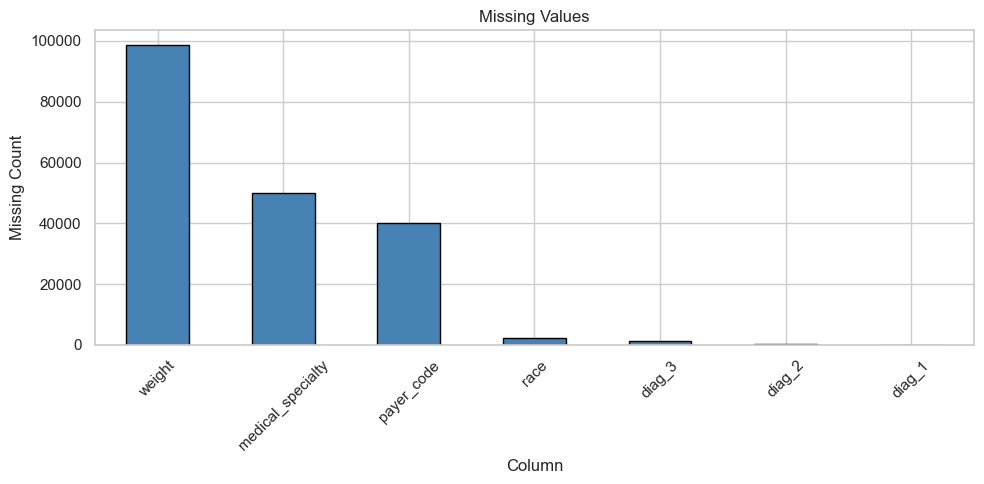

In [28]:
missing_pct = idXy.isnull().mean().sort_values(ascending=False) * 100
print('Missing value percentage per column:')
print(missing_pct[missing_pct > 0].to_string())

fig = plot_missing_values(idXy)
save_figure(fig, '01_missing_values.png')

### Remove Duplicates

There are no duplicates to drop.

In [29]:
int(X.duplicated().sum()), int(idXy.duplicated().sum())

(0, 0)

## 5. Univariate Analysis

Numeric columns: ['admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses']
Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_distributions.png


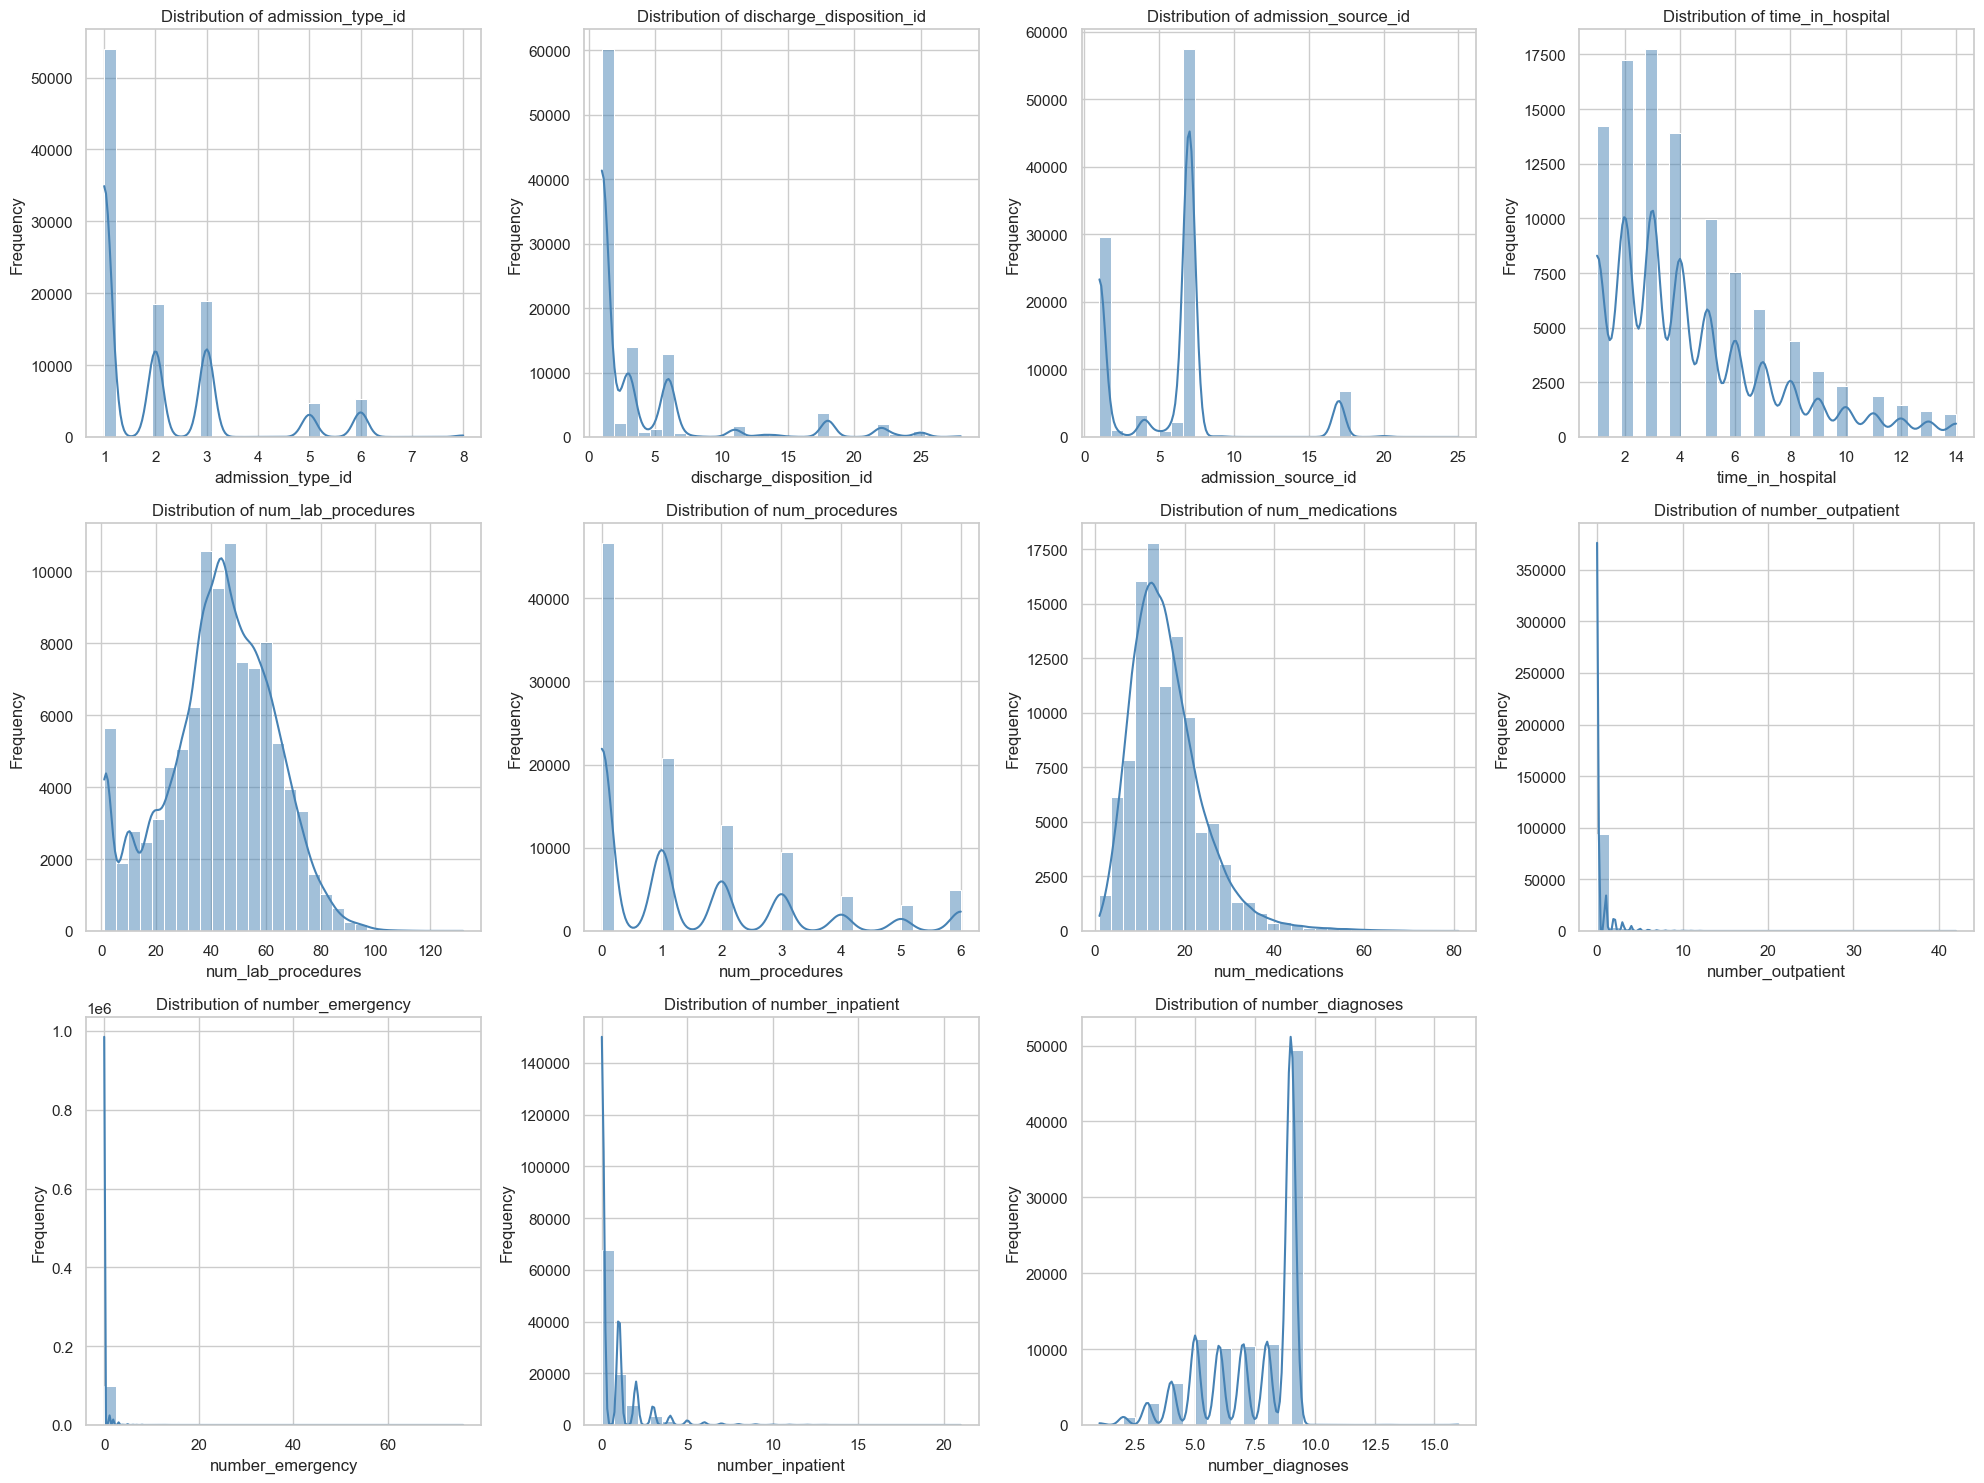

In [30]:
# The numeric columns, without the visit and patient IDs.
numeric_cols = idXy.select_dtypes(include=np.number).drop(columns=['encounter_id', 'patient_nbr']).columns.tolist()
print('Numeric columns:', numeric_cols)

# for col in numeric_cols:  # Limit to first 6 to keep output manageable
#     fig = plot_distribution(idXy, col)
#     save_figure(fig, f'01_dist_{col}.png')
#     plt.show()
fig = plot_distribution(idXy, numeric_cols, 3)
save_figure(fig, '01_distributions.png')
plt.show()

Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_boxplots.png


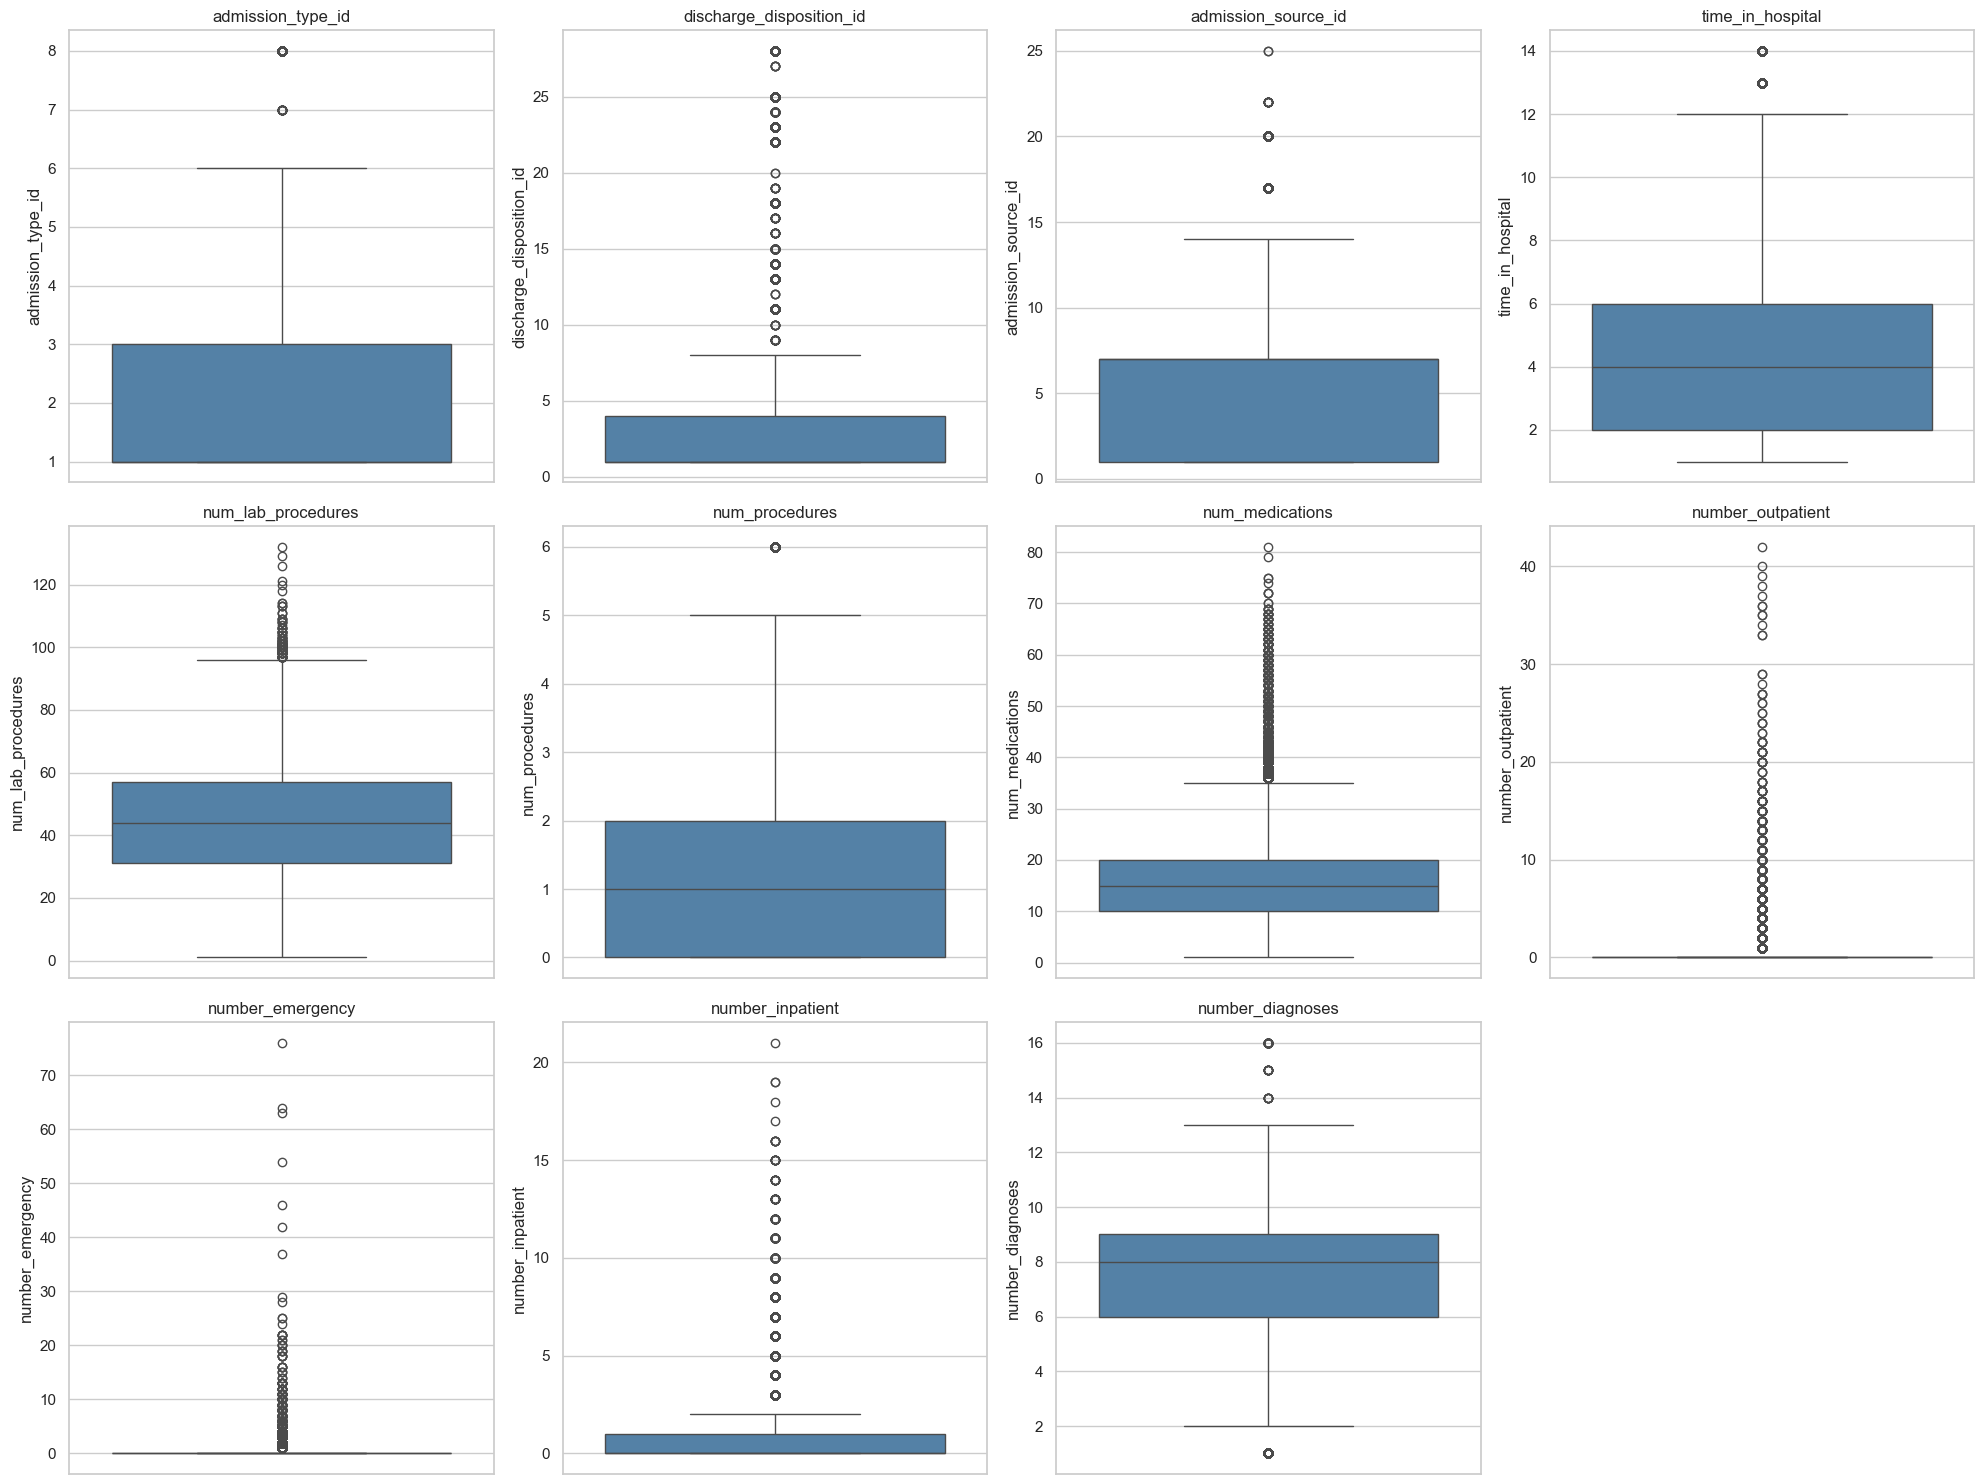

In [31]:
# Box plots for outlier detection
from src.visualization import plot_boxplots

fig = plot_boxplots(idXy, numeric_cols, 3)
save_figure(fig, '01_boxplots.png')
plt.show()


Categorical columns: ['race', 'gender', 'age', 'weight', 'payer_code', 'medical_specialty', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide', 'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide', 'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'insulin', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone', 'change', 'diabetesMed']
Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_counts.png


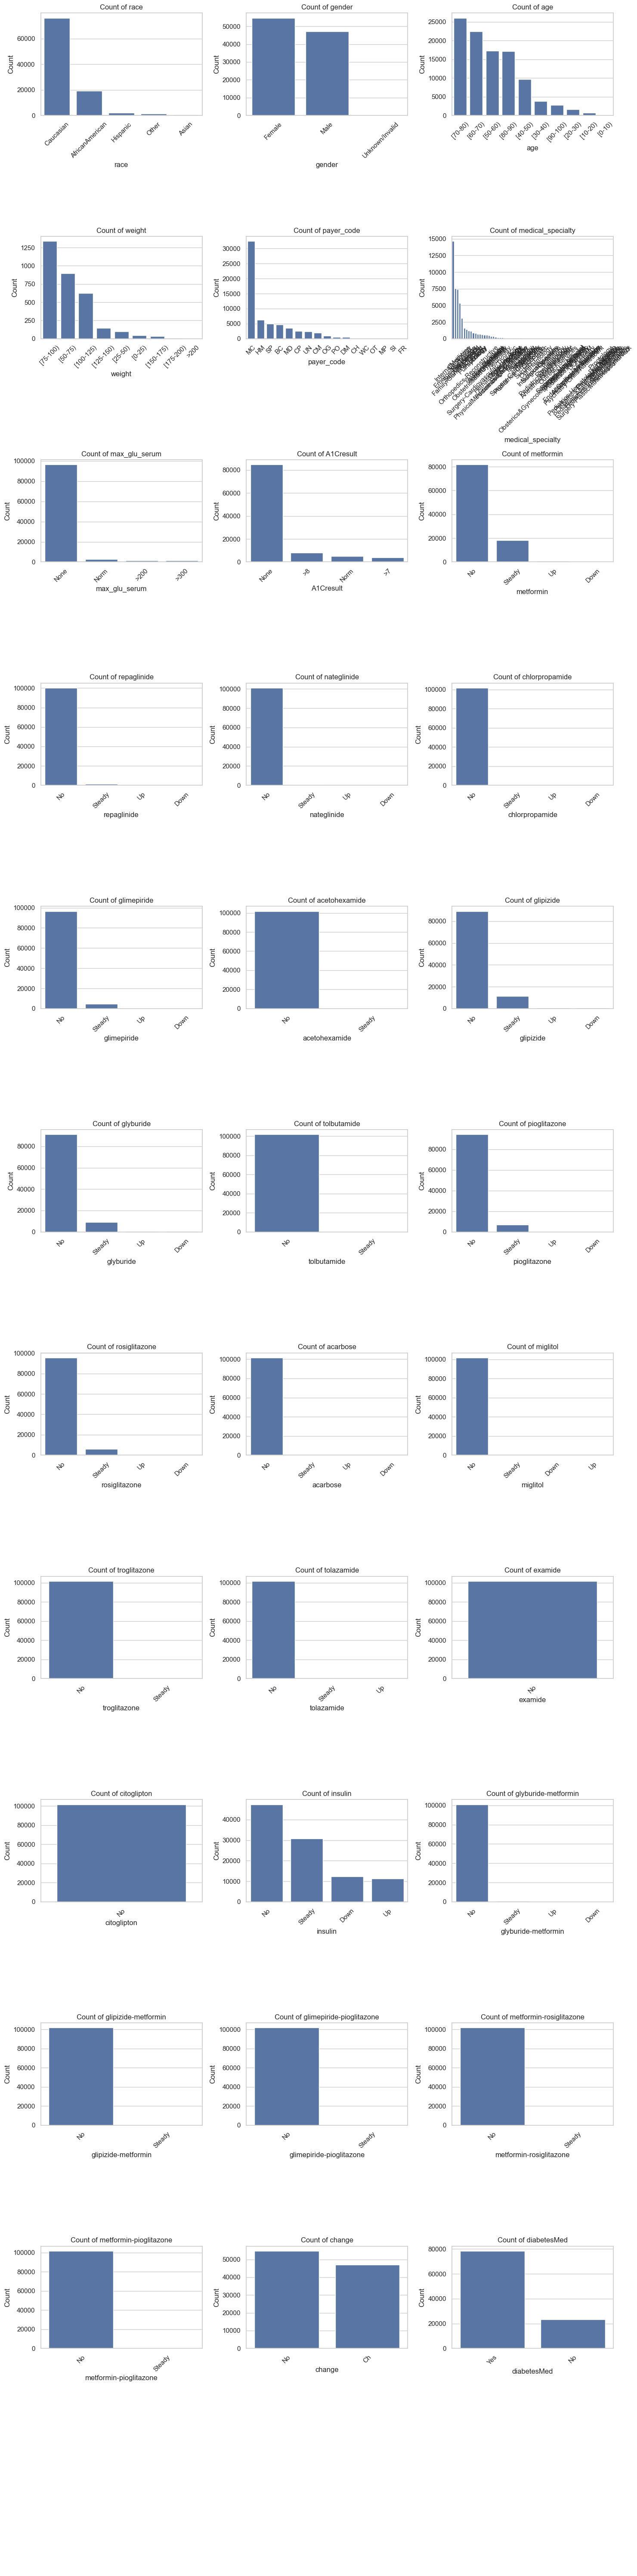

In [32]:
# Categorical columns

# let cat_cols be all columns in idXy where the type is str
cat_cols = idXy.select_dtypes(include=['str']).columns.tolist()

print('Categorical columns:', cat_cols)

# for col in cat_cols:
#     if (col != 'medical_specialty') and ('diag' not in col): # these have too many categories to plot
#         fig = plot_count(idXy, col)
#         save_figure(fig, f'01_count_{col}.png')
#         plt.show()
fig = plot_count(idXy, [c for c in cat_cols if 'diag' not in c], 12)
save_figure(fig, '01_counts.png')
plt.show()

In [33]:
idXy['medical_specialty'].value_counts()

medical_specialty
InternalMedicine          14635
Emergency/Trauma           7565
Family/GeneralPractice     7440
Cardiology                 5352
Surgery-General            3099
                          ...  
Dermatology                   1
SportsMedicine                1
Speech                        1
Perinatology                  1
Neurophysiology               1
Name: count, Length: 72, dtype: int64

In [34]:
idXy['diag_1'].value_counts()

diag_1
428    6862
414    6581
786    4016
410    3614
486    3508
       ... 
833       1
391       1
690       1
10        1
V51       1
Name: count, Length: 716, dtype: int64

In [35]:
idXy['diag_2'].value_counts()

diag_2
276    6752
428    6662
250    6071
427    5036
401    3736
       ... 
123       1
884       1
V60       1
843       1
927       1
Name: count, Length: 748, dtype: int64

In [36]:
idXy['diag_3'].value_counts()

diag_3
250    11555
401     8289
276     5175
428     4577
427     3955
       ...  
14         1
750        1
370        1
671        1
971        1
Name: count, Length: 789, dtype: int64

In [37]:
idXy['max_glu_serum'].value_counts(dropna=False)

max_glu_serum
None    96420
Norm     2597
>200     1485
>300     1264
Name: count, dtype: int64

## 6. Bivariate Analysis

In [38]:
# we have create a version of idXy where we have readmitted_binary which is 1 if and only if readmitted is '<30'
#idXy['readmitted_binary'] = idXy['readmitted'].apply(lambda x: 1 if x == '<30' else 0)
idXybin['readmitted_binary'].value_counts()


readmitted_binary
0    90409
1    11357
Name: count, dtype: int64

Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_correlation_heatmap.png


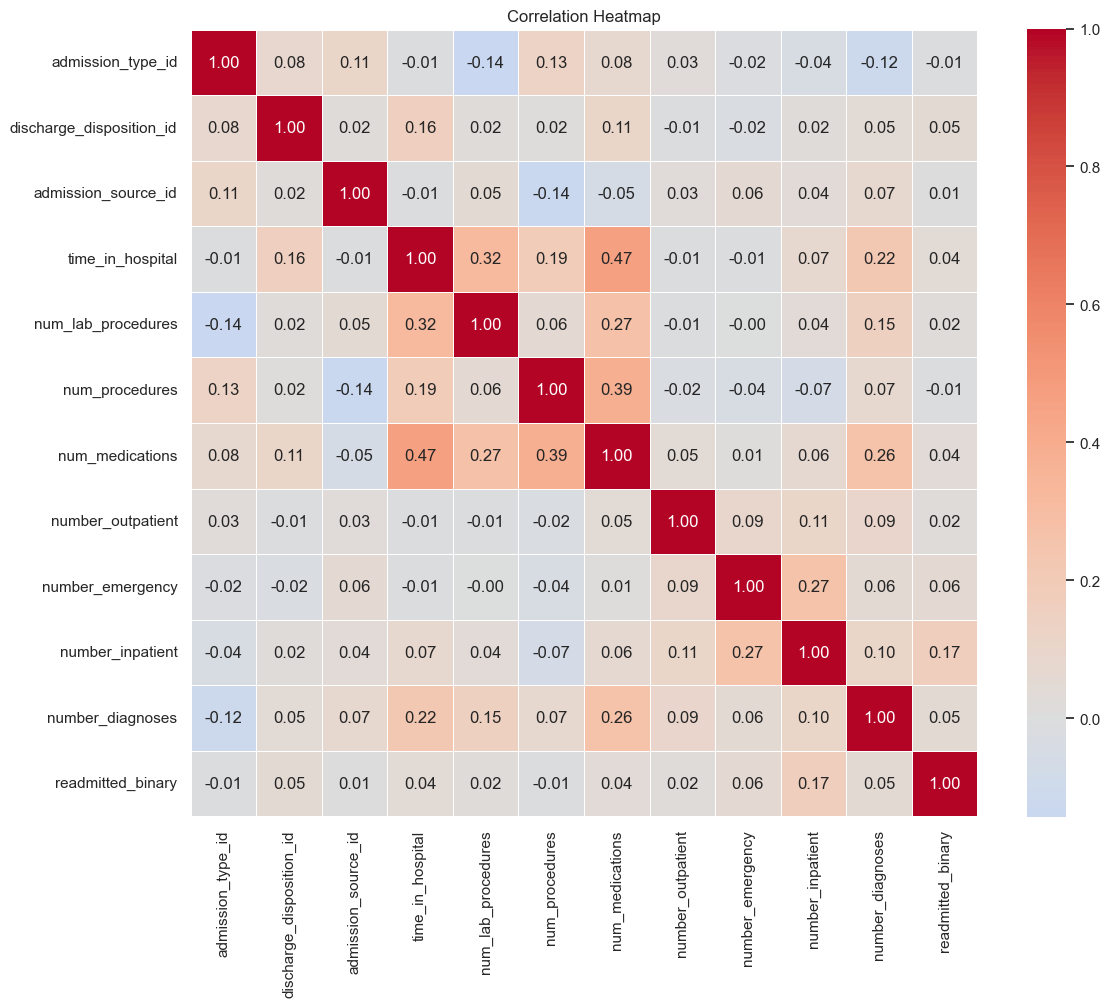

In [39]:
# Correlation heatmap
fig = plot_correlation_heatmap(idXybin.drop(columns=['encounter_id', 'patient_nbr']))
save_figure(fig, '01_correlation_heatmap.png')
plt.show()

Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_scatters.png


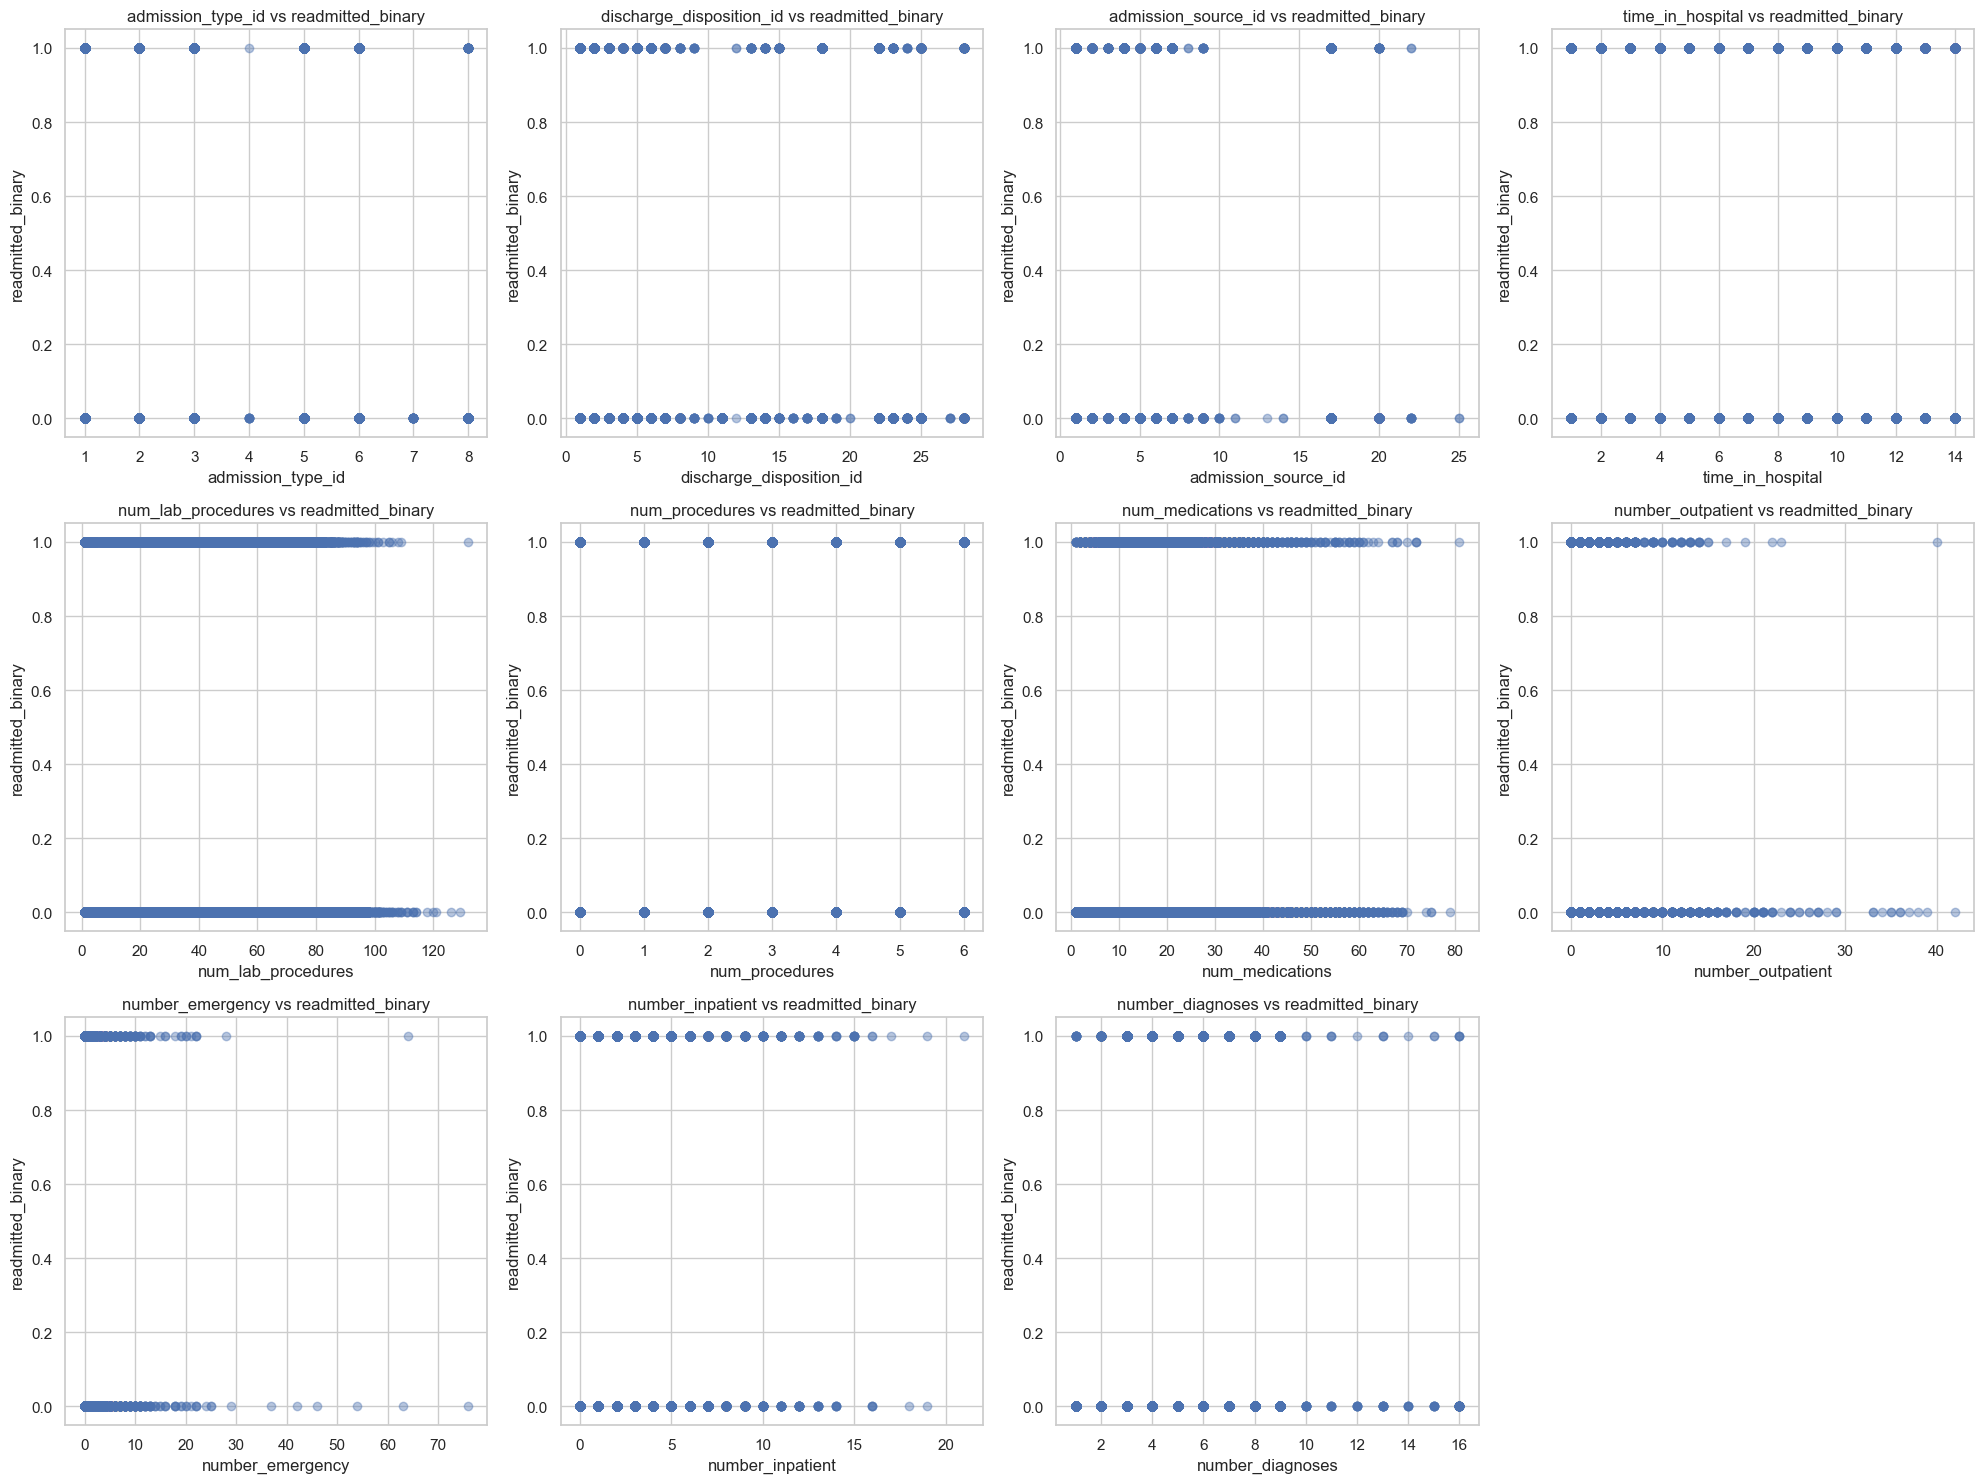

In [40]:
# TODO: Update target_column to your actual target variable.
target_column = 'readmitted_binary'  # <-- Change this

# if target_column in idXy.columns:
#     for col in numeric_cols:
#         if col != target_column:
#             fig, ax = plt.subplots(figsize=(6, 4))
#             ax.scatter(idXy[col], idXy[target_column], alpha=0.4)
#             ax.set_xlabel(col)
#             ax.set_ylabel(target_column)
#             ax.set_title(f'{col} vs {target_column}')
#             plt.tight_layout()
#             save_figure(fig, f'01_scatter_{col}_vs_{target_column}.png')
#             plt.show()
fig = plot_scatter(idXybin, numeric_cols, 3)
save_figure(fig, '01_scatters.png')
plt.show()

We might also want to know the cardinality of each column.

In [41]:
# calculate the cardinality of each column, and sort by cardinality
idXybin.nunique().sort_values(ascending=False)


encounter_id                101766
patient_nbr                  71518
diag_3                         789
diag_2                         748
diag_1                         716
num_lab_procedures             118
num_medications                 75
medical_specialty               72
number_outpatient               39
number_emergency                33
discharge_disposition_id        26
number_inpatient                21
payer_code                      17
admission_source_id             17
number_diagnoses                16
time_in_hospital                14
age                             10
weight                           9
admission_type_id                8
num_procedures                   7
race                             5
glipizide                        4
glyburide-metformin              4
insulin                          4
miglitol                         4
acarbose                         4
rosiglitazone                    4
pioglitazone                     4
glyburide           

## 7. Association Rules

Association rule mining is an unsupervised technique for discovering interesting co-occurrence patterns
in categorical data.  Given a set of transactions (here, patient encounters), the algorithm finds rules
of the form **{A, B} → {C}** — meaning items A and B frequently appear together with item C.

Three key metrics govern which rules are interesting:

| Metric | Meaning |
|---|---|
| **Support** | Fraction of encounters that contain the itemset. Higher support = more common pattern. |
| **Confidence** | P(consequent \| antecedent) — how reliably the right-hand side follows the left-hand side. |
| **Lift** | Confidence divided by the baseline probability of the consequent. Lift > 1 indicates a positive association beyond chance. |

We apply this to the diabetes dataset to surface hidden relationships among medications,
demographics, lab results, and readmission outcomes without pre-specifying a target variable.

In [42]:
medication_cols = [
    'metformin', 'repaglinide', 'nateglinide', 'chlorpropamide',
    'glimepiride', 'acetohexamide', 'glipizide', 'glyburide', 'tolbutamide',
    'pioglitazone', 'rosiglitazone', 'acarbose', 'miglitol', 'troglitazone',
    'tolazamide', 'insulin', 'glyburide-metformin', 'glipizide-metformin',
    'glimepiride-pioglitazone', 'metformin-rosiglitazone',
    'metformin-pioglitazone',
]
demographic_cols = ['age', 'race', 'gender']
clinical_cols = ['max_glu_serum', 'A1Cresult', 'change', 'diabetesMed', 'readmitted_binary']

ar_cols = medication_cols + demographic_cols + clinical_cols

ar_df = idXybin[ar_cols].copy()
ar_df['readmitted_binary'] = ar_df['readmitted_binary'].astype(str)

# One-hot encode every selected column into "column=value" boolean columns.
ar_encoded = pd.get_dummies(ar_df, prefix_sep='=')

# Drop "medication=No" columns for rarely prescribed drugs to reduce noise.
# Keep "No" only for the handful of widely prescribed meds where "No" is informative.
widely_prescribed = {'metformin', 'insulin', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone'}
drop_cols = [c for c in ar_encoded.columns
             if '=No' in c
             and c.split('=')[0] in medication_cols
             and c.split('=')[0] not in widely_prescribed]
ar_encoded.drop(columns=drop_cols, inplace=True)

ar_encoded = ar_encoded.astype(bool)
print(f'Transaction matrix: {ar_encoded.shape[0]:,} rows x {ar_encoded.shape[1]} items')
ar_encoded.head()

Transaction matrix: 101,766 rows x 86 items


,metformin=Down,metformin=No,metformin=Steady,metformin=Up,repaglinide=Down,repaglinide=Steady,repaglinide=Up,nateglinide=Down,nateglinide=Steady,nateglinide=Up,...,A1Cresult=>7,A1Cresult=>8,A1Cresult=None,A1Cresult=Norm,change=Ch,change=No,diabetesMed=No,diabetesMed=Yes,readmitted_binary=0,readmitted_binary=1
0,False,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,True,True,False,True,False
1,False,True,False,False,False,False,False,False,False,False,...,False,False,True,False,True,False,False,True,True,False
2,False,True,False,False,False,False,False,False,False,False,...,False,False,True,False,False,True,False,True,True,False
3,False,True,False,False,False,False,False,False,False,False,...,False,False,True,False,True,False,False,True,True,False
4,False,True,False,False,False,False,False,False,False,False,...,False,False,True,False,True,False,False,True,True,False


In [43]:
frequent_itemsets = fpgrowth(ar_encoded, min_support=0.05, use_colnames=True)
print(f'Frequent itemsets found: {len(frequent_itemsets)}')

rules = association_rules(frequent_itemsets, metric='lift', min_threshold=1.2)
rules = rules.sort_values('lift', ascending=False).reset_index(drop=True)
print(f'Association rules (lift >= 1.2): {len(rules)}')

rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

Frequent itemsets found: 48220
Association rules (lift >= 1.2): 2898520


,antecedents,consequents,support,confidence,lift
0,"frozenset({race=Caucasian, diabetesMed=No})","frozenset({rosiglitazone=No, insulin=No, piogl...",0.063499,0.366140,4.135010
1,"frozenset({insulin=No, rosiglitazone=No, piogl...","frozenset({race=Caucasian, diabetesMed=No})",0.063499,0.717124,4.135010
2,"frozenset({readmitted_binary=0, diabetesMed=No...","frozenset({race=Caucasian, rosiglitazone=No, i...",0.063499,0.782514,4.134004
3,"frozenset({race=Caucasian, rosiglitazone=No, i...","frozenset({readmitted_binary=0, diabetesMed=No...",0.063499,0.335462,4.134004
4,"frozenset({diabetesMed=No, A1Cresult=None, gen...","frozenset({race=Caucasian, rosiglitazone=No, i...",0.070348,0.779423,4.117674
5,"frozenset({race=Caucasian, rosiglitazone=No, i...","frozenset({diabetesMed=No, A1Cresult=None, gen...",0.070348,0.371645,4.117674
6,"frozenset({insulin=No, rosiglitazone=No, piogl...","frozenset({race=Caucasian, diabetesMed=No})",0.070348,0.713901,4.116429
7,"frozenset({race=Caucasian, diabetesMed=No})","frozenset({insulin=No, rosiglitazone=No, piogl...",0.070348,0.405632,4.116429
8,"frozenset({insulin=No, rosiglitazone=No, piogl...","frozenset({race=Caucasian, diabetesMed=No, max...",0.067419,0.665793,4.115350
9,"frozenset({race=Caucasian, diabetesMed=No, max...","frozenset({insulin=No, rosiglitazone=No, piogl...",0.067419,0.416727,4.115350


### How to read the rules

Each row in the table above is a rule **{antecedents} → {consequents}**:

- **Support** — the proportion of all encounters where both the antecedent and consequent items co-occur.
  A higher support means the pattern is more prevalent in the dataset.
- **Confidence** — P(consequent | antecedent).  A confidence of 0.80 means that 80% of encounters
  containing the antecedent items also contain the consequent items.
- **Lift** — confidence / P(consequent).  Lift > 1 signals a positive association stronger than
  what we would expect by chance; lift < 1 signals a negative (repulsive) association.

Rules with **high lift _and_ reasonable support** are the most interesting — they represent
strong, non-trivial patterns that occur frequently enough to be clinically meaningful.

Figure saved to /Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/figures/01_association_rules.png


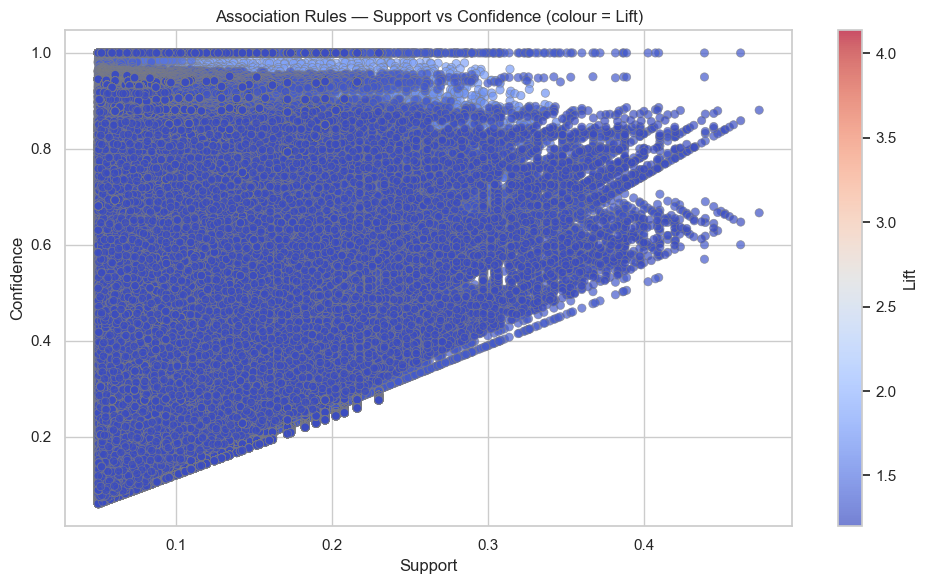

In [44]:
fig = plot_association_rules(rules, title='Association Rules — Support vs Confidence (colour = Lift)')
save_figure(fig, '01_association_rules.png')
plt.show()

In [45]:
readmission_items = {'readmitted_binary=1', 'readmitted_binary=0'}

def involves_readmission(row):
    return bool((set(row['antecedents']) | set(row['consequents'])) & readmission_items)

readmit_rules = rules[rules.apply(involves_readmission, axis=1)].copy()
readmit_rules = readmit_rules.sort_values('confidence', ascending=False).reset_index(drop=True)
print(f'Rules involving readmitted_binary: {len(readmit_rules)}')

readmit_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(20)

Rules involving readmitted_binary: 1805720


,antecedents,consequents,support,confidence,lift
0,"frozenset({max_glu_serum=None, A1Cresult=None,...","frozenset({pioglitazone=No, rosiglitazone=No, ...",0.171413,1.0,1.406715
1,"frozenset({insulin=No, rosiglitazone=No, max_g...","frozenset({pioglitazone=No, glipizide=No})",0.095494,1.0,1.224754
2,"frozenset({race=Caucasian, rosiglitazone=No, i...","frozenset({pioglitazone=No, glipizide=No})",0.067419,1.0,1.224754
3,"frozenset({race=Caucasian, diabetesMed=No, rea...","frozenset({pioglitazone=No, glipizide=No})",0.072234,1.0,1.224754
4,"frozenset({insulin=No, A1Cresult=None, diabete...","frozenset({pioglitazone=No, glipizide=No})",0.101596,1.0,1.224754
5,"frozenset({race=Caucasian, rosiglitazone=No, i...","frozenset({pioglitazone=No, glipizide=No})",0.067419,1.0,1.224754
6,"frozenset({race=Caucasian, rosiglitazone=No, m...","frozenset({pioglitazone=No, glipizide=No})",0.058939,1.0,1.224754
7,"frozenset({diabetesMed=Yes, rosiglitazone=No, ...","frozenset({pioglitazone=No, glipizide=No})",0.060963,1.0,1.224754
8,"frozenset({insulin=Steady, readmitted_binary=0...","frozenset({pioglitazone=No, glipizide=No})",0.141216,1.0,1.224754
9,"frozenset({diabetesMed=Yes, metformin=No, insu...","frozenset({pioglitazone=No, glipizide=No})",0.141216,1.0,1.224754


In [46]:
readmit_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5)

,antecedents,consequents,support,confidence,lift
0,"frozenset({max_glu_serum=None, A1Cresult=None,...","frozenset({pioglitazone=No, rosiglitazone=No, ...",0.171413,1.0,1.406715
1,"frozenset({insulin=No, rosiglitazone=No, max_g...","frozenset({pioglitazone=No, glipizide=No})",0.095494,1.0,1.224754
2,"frozenset({race=Caucasian, rosiglitazone=No, i...","frozenset({pioglitazone=No, glipizide=No})",0.067419,1.0,1.224754
3,"frozenset({race=Caucasian, diabetesMed=No, rea...","frozenset({pioglitazone=No, glipizide=No})",0.072234,1.0,1.224754
4,"frozenset({insulin=No, A1Cresult=None, diabete...","frozenset({pioglitazone=No, glipizide=No})",0.101596,1.0,1.224754


In [49]:
# save to a csv file 
readmit_rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(5).to_csv('/Users/chrisindris/Documents/PhD/CP8305-KD/Project/CP8305FP/reports/tables/association_rules_readmission.csv', index=False)

### Key findings

_Fill in after running the cells above._

- **Medication co-occurrence:** ...
- **Demographics & outcomes:** ...
- **Readmission-related patterns:** ...

## 8. Initial Observations

_Use this section to summarise what you found during exploration._

- **Dataset size:** 101766 rows, 50 columns (incl. the target and two ID columns for visit and patient)
- **Key features:** 
- **Missing data:** yes
- **Potential outliers:** yes
- **Interesting correlations:** num_inpatient seems to be best correlated with readmitted; see section 7 for association rules
- **Next steps:** See Notebook 2 – Data Preprocessing.